# BRFSS 2015 Diabetes Health Indicators — Exploratory Data Analysis

**Authors:** Wolfgang Klein, Sydney Bailey, Harvey Luna, Nashita Kandaker
**Data:** `diabetes_012_health_indicators_BRFSS2015.csv`, with the three-class
target collapsed to binary: 253,680 respondents, 21 features, one binary target

This notebook explores the structure of the dataset before any modelling. It works
through five questions in order:

1. **What is this file, and what does the target actually measure?**
2. **Is the data clean in the ways that matter?** Ranges, duplicates, and the shape of each variable.
3. **How does diabetes prevalence move with each feature?** Direction, size, and shape of each association.
4. **What structure connects the features to each other?** Redundancy, clustering, and joint effects.
5. **Who is missing from the positive class?** The target records a diagnosis, so
   anyone never screened is coded negative regardless of disease status. §11 and the
   appendix quantify that population and locate it.

Each section closes with a short takeaway describing what the finding means for
the modelling stage. The appendix ends with the modelling plan those takeaways
imply: train on the screened respondents, apply to the never-screened.

## 0. Setup

In [130]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PALETTE = {
    "ink":    "#22303c",
    "grid":   "#dfe4e8",
    "neg":    "#8fa3b0",   # reference / unexposed
    "pos":    "#b5442e",   # diabetes / elevated
    "prot":   "#2f6f6a",   # protective direction
    "accent": "#c98a1b",
}
SEQ = sns.blend_palette(["#f5f2ea", "#d8b26a", "#b5442e", "#5c1d13"], as_cmap=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10.5, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "axes.edgecolor": PALETTE["grid"],
    "axes.grid": True, "grid.color": PALETTE["grid"], "grid.linewidth": 0.7,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "text.color": PALETTE["ink"], "axes.labelcolor": PALETTE["ink"],
    "xtick.color": PALETTE["ink"], "ytick.color": PALETTE["ink"],
    "legend.frameon": False, "figure.facecolor": "white",
})

# category labels shared by Section 2.1 and the Section 6 panels
AGE_LAB = ["18-24","25-29","30-34","35-39","40-44","45-49","50-54",
           "55-59","60-64","65-69","70-74","75-79","80+"]
EDU_LAB = ["never\nattended","elementary","some HS","HS grad","some\ncollege","college\ngrad"]
INC_LAB = ["<10k","10-15k","15-20k","20-25k","25-35k","35-50k","50-75k",">=75k"]

print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.2 | numpy 2.4.4 | seaborn 0.13.2


In [131]:
import os

PATH = "../data/diabetes_012_health_indicators_BRFSS2015.csv"
assert os.path.exists(PATH), f"Dataset not found at {PATH}. See README for setup."

raw = pd.read_csv(PATH)

# Kaggle's binary-target release is this file's 3-class target collapsed:
# prediabetes and diabetes merged into one positive class. Verified against
# this file -- the resulting prevalence (15.76%) matches the published binary
# variant's known class balance.
raw["Diabetes_binary"] = (raw["Diabetes_012"] > 0).astype(float)
raw = raw.drop(columns="Diabetes_012")
raw = raw[["Diabetes_binary"] + [c for c in raw.columns if c != "Diabetes_binary"]]

TARGET   = "Diabetes_binary"
FEATURES = [c for c in raw.columns if c != TARGET]

print(f"loaded  : {PATH}")
print(f"shape   : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"target  : {TARGET}, prevalence {100*raw[TARGET].mean():.2f}%")

loaded  : ../data/diabetes_012_health_indicators_BRFSS2015.csv
shape   : 253,680 rows x 22 columns
target  : Diabetes_binary, prevalence 15.76%


Two helpers used throughout. Because every association here is a proportion, the
Wilson interval is the right uncertainty band — it behaves properly near 0 and 1,
where several of these prevalences sit.

In [132]:
def wilson(k, n, z=1.96):
    '''Wilson score interval for a binomial proportion.'''
    p   = k / n
    den = 1 + z*z/n
    ctr = (p + z*z/(2*n)) / den
    hw  = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return ctr - hw, ctr + hw


def prevalence_by_level(col, df=None):
    '''Diabetes prevalence at each level of a column, with Wilson bounds.'''
    df = raw if df is None else df
    g = df.groupby(col, observed=True)[TARGET].agg(n="size", k="sum")
    g["prev"] = g.k / g.n
    lo, hi = zip(*[wilson(k, n) for k, n in zip(g.k, g.n)])
    g["lo"], g["hi"] = lo, hi
    return g

print("helpers ready")

helpers ready


---
## 1. What this file is

The Behavioral Risk Factor Surveillance System (BRFSS) is an annual CDC telephone
survey. The 2015 wave interviewed 441,455 people across roughly 330 variables.
This file is a derived extract: 253,680 complete cases on 22 hand-picked columns.

Four properties of that extract shape everything downstream.

**The survey design weights are absent.** BRFSS uses stratified random-digit
dialling; the analysis weight `_LLCPWT`, together with `_STSTR` and `_PSU`,
converts the sample into a population estimate. Those columns are not in this
file. Every proportion computed here therefore describes **this sample**, not US
adults.

**The geography identifier is absent.** Without `_STATE` there is no key for
joining external data, and real between-state variation in prevalence is folded
into unmodelled noise.

**Refusal codes were collapsed upstream.** In the source data `MENTHLTH` and
`PHYSHLTH` use `88` for "none", `77` for "don't know" and `99` for "refused". Here
those columns run 0–30 with no missing values: the 88s became 0s, and the 77s and
99s were dropped along with their rows.

**The target is a self-reported diagnosis, not a lab value.** `Diabetes_binary`
records whether a respondent was *ever told by a doctor* that they have diabetes.
Undiagnosed diabetics are coded as negatives. The label therefore measures
diagnosed diabetes, which is diabetes filtered through healthcare access. Section
11 shows this leaves a clear signature in the data.

In [133]:
DICT = pd.DataFrame([
 ("Diabetes_binary","target","binary","0/1","Ever told by a doctor you have diabetes (gestational excluded)"),
 ("HighBP","clinical","binary","0/1","Ever told you have high blood pressure"),
 ("HighChol","clinical","binary","0/1","Ever told your blood cholesterol is high"),
 ("CholCheck","access","binary","0/1","Cholesterol checked within past 5 years"),
 ("BMI","anthropometric","count","12-98","Body mass index from self-reported height & weight"),
 ("Smoker","behaviour","binary","0/1","Smoked >=100 cigarettes in lifetime"),
 ("Stroke","clinical","binary","0/1","Ever told you had a stroke"),
 ("HeartDiseaseorAttack","clinical","binary","0/1","Ever reported CHD or myocardial infarction"),
 ("PhysActivity","behaviour","binary","0/1","Any physical activity in past 30 days outside of work"),
 ("Fruits","behaviour","binary","0/1","Consumes fruit >=1 time per day"),
 ("Veggies","behaviour","binary","0/1","Consumes vegetables >=1 time per day"),
 ("HvyAlcoholConsump","behaviour","binary","0/1","Heavy drinker (M >14, F >7 drinks/week)"),
 ("AnyHealthcare","access","binary","0/1","Has any health care coverage"),
 ("NoDocbcCost","access","binary","0/1","Needed a doctor in past 12m but could not afford one"),
 ("GenHlth","self-rated","ordinal","1-5","Self-rated general health: 1=Excellent ... 5=Poor"),
 ("MentHlth","self-rated","count","0-30","Days in past 30 mental health was not good"),
 ("PhysHlth","self-rated","count","0-30","Days in past 30 physical health was not good"),
 ("DiffWalk","functional","binary","0/1","Serious difficulty walking or climbing stairs"),
 ("Sex","demographic","binary","0/1","0 = Female, 1 = Male"),
 ("Age","demographic","ordinal","1-13","5-year bands: 1 = 18-24 ... 13 = 80+"),
 ("Education","socio-economic","ordinal","1-6","1 = never attended ... 6 = college graduate"),
 ("Income","socio-economic","ordinal","1-8","1 = <$10k ... 8 = >=$75k"),
], columns=["variable","block","type","range","meaning"])

DICT.set_index("variable")

,block,type,range,meaning
variable,,,,
Diabetes_binary,target,binary,0/1,Ever told by a doctor you have diabetes (gesta...
HighBP,clinical,binary,0/1,Ever told you have high blood pressure
HighChol,clinical,binary,0/1,Ever told your blood cholesterol is high
CholCheck,access,binary,0/1,Cholesterol checked within past 5 years
BMI,anthropometric,count,12-98,Body mass index from self-reported height & we...
Smoker,behaviour,binary,0/1,Smoked >=100 cigarettes in lifetime
Stroke,clinical,binary,0/1,Ever told you had a stroke
HeartDiseaseorAttack,clinical,binary,0/1,Ever reported CHD or myocardial infarction
PhysActivity,behaviour,binary,0/1,Any physical activity in past 30 days outside ...


> **Takeaway.** Report results as sample statistics, not population estimates, and
> note that roughly 40% of original BRFSS respondents are absent by construction.
> Read `GenHlth` in the codebook direction: **1 is excellent health, 5 is poor**.

---
## 2. Structural audit

`raw.isnull().sum().sum()` returns 0. That tells us the recode left no gaps; it
does not tell us the data is sound. Three checks follow: whether the sample resembles the US population it is
meant to describe, whether every column stays inside its codebook range, and
whether each column's shape within that range looks like a measurement.

### 2.1 How the sample compares with the 2015 US population

Section 1 flagged two facts about this file: the BRFSS design weights are absent,
and roughly 40% of the original respondents were removed by a complete-case
filter. Together they mean the sample's demographic marginals need not match the
US adult population, and wherever they do not, the prevalences in Sections 6 and
8 are shifted away from population values.

This section measures that gap on the three demographic axes the file carries:
**age**, **household income**, and **educational attainment**. The reference is
the **2015 American Community Survey 1-year** release, pulled from the Census API
(`B01001` for age, `B19001` for household income, `B15003` for education), with
each ACS bracket set collapsed onto the BRFSS coding.

The BRFSS and ACS misalign on three pints. BRFSS `Income` is reported by each
adult about their household, whereas the ACS distribution is over households, so
the two do not share a base exactly. ACS educational attainment is tabulated for
ages 25 and over, against a BRFSS frame of 18 and over. And the BRFSS income and
education non-responses were dropped before this CSV was written (Section 2.2),
while the ACS imputes them. ACS margins of error are negligible at national scale
and are not shown.

The Census API requires a free key as of 2025. If you want to reproduce this analysis exactly, set it in the `CENSUS_API_KEY`
environment variable before running the next cell. The pulled distributions are
cached to `cache/census_2015_reference.json`. The notebook will run using the cached data.


In [134]:
import json, os, urllib.request, urllib.parse, urllib.error
from datetime import date
from pathlib import Path

CENSUS_BASE = "https://api.census.gov/data/2015/acs/acs1"
CACHE       = Path("cache/census_2015_reference.json")

# --- ACS detailed-table bracket -> BRFSS band crosswalks -----------------------
# Age: B01001 "Sex by Age". Both-sex count = male estimate + female estimate,
# and the female variable index is always the male index + 24.
ACS_AGE_MALE = {
    1:  [7, 8, 9, 10],        # 18-19, 20, 21, 22-24
    2:  [11], 3: [12], 4: [13], 5: [14], 6: [15], 7: [16], 8: [17],
    9:  [18, 19],             # 60-61, 62-64
    10: [20, 21],             # 65-66, 67-69
    11: [22], 12: [23],
    13: [24, 25],             # 80-84, 85+
}
# Income: B19001 "Household Income". For the 2015 vintage the ACS brackets break
# at $10/15/20/25/35/50/75k, so every BRFSS INCOME2 cutpoint lands on an ACS
# boundary and the mapping is lossless. 
ACS_INC = {
    1: [2], 2: [3], 3: [4], 4: [5],
    5: [6, 7],                # 25-29,999 + 30-34,999
    6: [8, 9, 10],            # 35-39,999 + 40-44,999 + 45-49,999
    7: [11, 12],              # 50-59,999 + 60-74,999
    8: [13, 14, 15, 16, 17],  # 75,000 and over
}
# Education: B15003 "Educational Attainment", population 25 and over.
# _016E ("12th grade, no diploma") is counted as "some HS" (did not graduate),
# not "HS grad". Associate's degree (_021E) goes with "some college".
ACS_EDU = {
    1: [2, 3, 4],                      # no schooling, nursery, kindergarten
    2: [5, 6, 7, 8, 9, 10, 11, 12],    # grades 1-8
    3: [13, 14, 15, 16],              # grades 9-11, plus 12th no diploma
    4: [17, 18],                      # regular HS diploma, GED
    5: [19, 20, 21],                  # some college <1yr, 1+yr no degree, associate's
    6: [22, 23, 24, 25],             # bachelor's, master's, professional, doctorate
}


def _acs_get(varlist):
    """One GET against the 2015 ACS 1-year API. Returns {variable: int}."""
    params = {"get": "NAME," + ",".join(varlist), "for": "us:1"}
    key = os.environ.get("CENSUS_API_KEY")          # you need to set your environment variable
    if key:
        params["key"] = key
    url = CENSUS_BASE + "?" + urllib.parse.urlencode(params)
    req = urllib.request.Request(url, headers={"User-Agent": "brfss-eda/1.0"})
    for attempt in range(2):
        try:
            with urllib.request.urlopen(req, timeout=30) as resp:
                body = resp.read()
            rows = json.loads(body)                  # [header_row, value_row]
            header, values = rows[0], rows[1]
            return {name: (int(v) if v not in (None, "") else None)
                    for name, v in zip(header, values) if name in varlist}
        except json.JSONDecodeError:
            why = "the API now requires a key" if not key else "the key may be invalid"
            raise RuntimeError(
                f"Census API did not return JSON ({why}). Get a free key at "
                "https://api.census.gov/data/key_signup.html and set CENSUS_API_KEY. "
                f"Response began: {body[:160].decode('utf-8', 'replace')!r}"
            ) from None
        except urllib.error.HTTPError as e:
            if e.code < 500 or attempt == 1:
                raise


def build_reference():
    """Pull the three ACS tables and collapse each to the BRFSS band scheme."""
    male = sorted({i for lst in ACS_AGE_MALE.values() for i in lst})
    a = _acs_get([f"B01001_{i:03d}E" for i in male + [j + 24 for j in male]])
    age_counts = [sum(a[f"B01001_{i:03d}E"] + a[f"B01001_{i + 24:03d}E"]
                      for i in ACS_AGE_MALE[b]) for b in range(1, 14)]

    inc = _acs_get([f"B19001_{i:03d}E" for i in range(2, 18)])
    inc_counts = [sum(inc[f"B19001_{i:03d}E"] for i in ACS_INC[b]) for b in range(1, 9)]

    edu = _acs_get([f"B15003_{i:03d}E" for i in range(2, 26)])
    edu_counts = [sum(edu[f"B15003_{i:03d}E"] for i in ACS_EDU[b]) for b in range(1, 7)]

    ref = {"meta": {
        "source": "U.S. Census Bureau, 2015 American Community Survey 1-year estimates",
        "endpoint": CENSUS_BASE, "geography": "us:1",
        "tables": {"age": "B01001", "income": "B19001", "education": "B15003"},
        "retrieved": str(date.today()),
        "notes": ("age = both-sex population 18+; income = households; education = "
                  "population 25+. 2015 B19001 brackets nest exactly into the BRFSS "
                  "INCOME2 cutpoints; B15003_016E counted as 'some HS'."),
    }}
    for name, counts, labels in [("age", age_counts, AGE_LAB),
                                 ("income", inc_counts, INC_LAB),
                                 ("education", edu_counts,
                                  [l.replace("\n", " ") for l in EDU_LAB])]:
        base = sum(counts)
        ref[name] = {"labels": list(labels), "counts": counts,
                     "base": base, "share": [c / base for c in counts]}
    return ref


if CACHE.exists():
    ref, source = json.loads(CACHE.read_text()), "cache"
else:
    ref = build_reference()
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    CACHE.write_text(json.dumps(ref, indent=2))
    source = "api"

for dim in ("age", "income", "education"):
    assert abs(sum(ref[dim]["share"]) - 1.0) < 1e-9, dim

print(f"census reference [{source}]   US pop 18+ {ref['age']['base']:,}   "
      f"households {ref['income']['base']:,}   US pop 25+ {ref['education']['base']:,}")


census reference [cache]   US pop 18+ 247,789,111   households 118,208,250   US pop 25+ 216,447,163


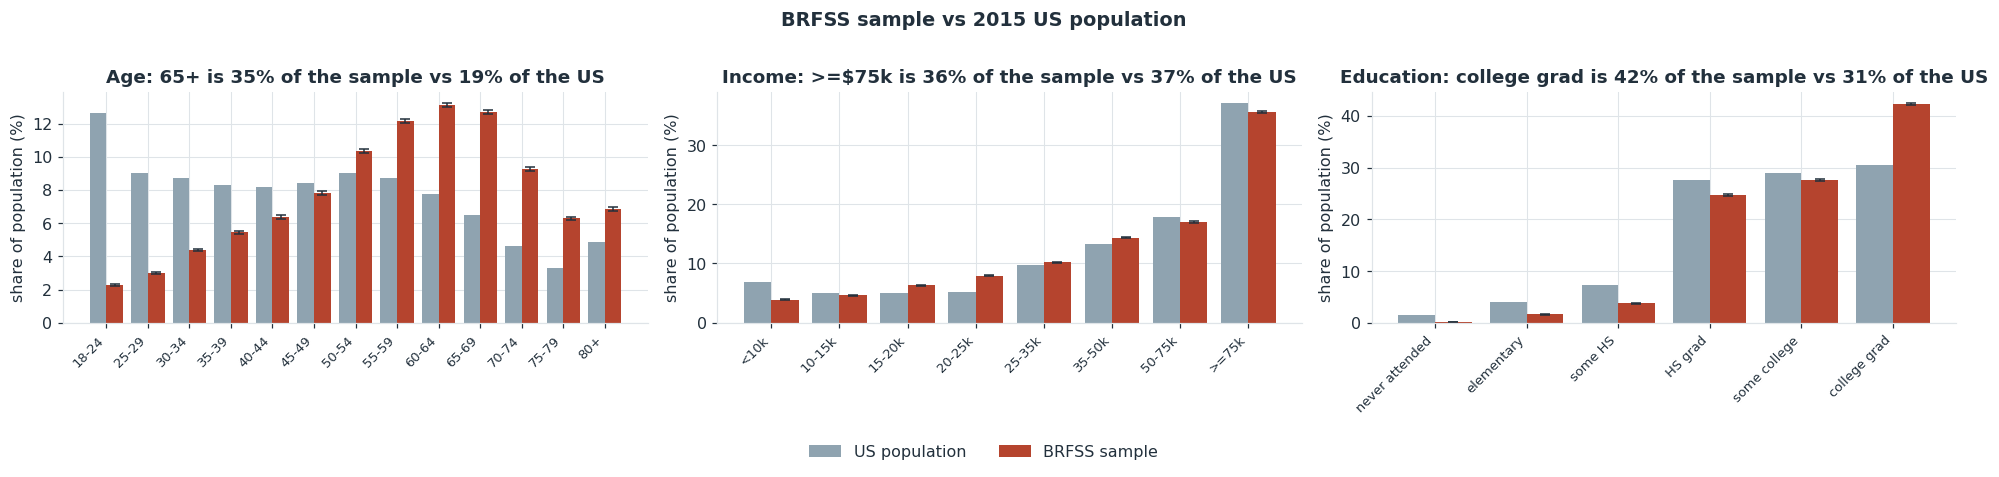

age      : widest gap at '18-24'  2.2% sample vs 12.6% US  (-10.4 pts)
income   : widest gap at '<10k'  3.9% sample vs 6.9% US  (-3.0 pts)
education: widest gap at 'college grad'  42.3% sample vs 30.6% US  (+11.7 pts)


In [135]:
BANDS = {"age": (range(1, 14), AGE_LAB), "income": (range(1, 9), INC_LAB),
         "education": (range(1, 7), EDU_LAB)}
COLS  = {"age": "Age", "income": "Income", "education": "Education"}
HEAD  = {"age": (slice(9, 13), "65+"), "income": (slice(7, 8), ">=$75k"),
         "education": (slice(5, 6), "college grad")}


def _sample_share(dim):
    rng = BANDS[dim][0]
    cnt = raw[COLS[dim]].value_counts().reindex(rng, fill_value=0).to_numpy()
    return cnt, cnt / cnt.sum()


fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
for ax, dim in zip(axes, ("age", "income", "education")):
    labs   = [l.replace("\n", " ") for l in BANDS[dim][1]]
    us     = np.array(ref[dim]["share"])
    cnt, samp = _sample_share(dim)
    lo, hi = map(np.array, zip(*[wilson(int(k), int(cnt.sum())) for k in cnt]))
    x = np.arange(len(labs)); w = .4
    ax.bar(x - w / 2, 100 * us,   w, color=PALETTE["neg"], label="US population")
    ax.bar(x + w / 2, 100 * samp, w, color=PALETTE["pos"], label="BRFSS sample",
           yerr=[100 * (samp - lo), 100 * (hi - samp)],
           error_kw=dict(ecolor=PALETTE["ink"], lw=1, capsize=3))
    ax.set_xticks(x); ax.set_xticklabels(labs, rotation=45, ha="right", fontsize=8.5)
    ax.set_ylabel("share of population (%)")
    sl, name = HEAD[dim]
    ax.set_title(f"{dim.capitalize()}: {name} is {100 * samp[sl].sum():.0f}% of the "
                 f"sample vs {100 * us[sl].sum():.0f}% of the US")
fig.suptitle("BRFSS sample vs 2015 US population", fontweight="bold")
handles, labels = axes[0].get_legend_handles_labels()
fig.tight_layout(rect=(0, 0.09, 1, 0.97))

fig.legend(handles=handles, labels=labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.0))
plt.show()

for dim in ("age", "income", "education"):
    labs = [l.replace("\n", " ") for l in BANDS[dim][1]]
    us   = np.array(ref[dim]["share"])
    _, samp = _sample_share(dim)
    j = int(np.abs(samp - us).argmax())
    print(f"{dim:9s}: widest gap at '{labs[j]}'  "
          f"{100 * samp[j]:.1f}% sample vs {100 * us[j]:.1f}% US  ({100 * (samp[j] - us[j]):+.1f} pts)")


In [136]:
rows, tvd = [], {}
for dim in ("age", "income", "education"):
    labs   = [l.replace("\n", " ") for l in BANDS[dim][1]]
    us     = np.array(ref[dim]["share"])
    cnt, samp = _sample_share(dim)
    lo, hi = zip(*[wilson(int(k), int(cnt.sum())) for k in cnt])
    tvd[dim] = 0.5 * np.abs(samp - us).sum()
    for i, lab in enumerate(labs):
        rows.append({"dimension": dim, "band": lab,
                     "US %": 100 * us[i], "sample %": 100 * samp[i],
                     "diff (pts)": 100 * (samp[i] - us[i]),
                     "sample 95% CI": f"[{100 * lo[i]:.2f}, {100 * hi[i]:.2f}]"})

diff_table = pd.DataFrame(rows)
display(diff_table.round(2))

print("total variation distance from a representative sample (0 = identical, "
      "1 = disjoint):")
for dim, v in tvd.items():
    print(f"  {dim:9s} {v:.3f}")


,dimension,band,US %,sample %,diff (pts),sample 95% CI
0,age,18-24,12.6500,2.2500,-10.4000,"[2.19, 2.31]"
1,age,25-29,9.0000,3.0000,-6.0000,"[2.93, 3.06]"
2,age,30-34,8.7200,4.3800,-4.3300,"[4.31, 4.47]"
3,age,35-39,8.2700,5.4500,-2.8200,"[5.36, 5.54]"
4,age,40-44,8.2000,6.3700,-1.8300,"[6.27, 6.46]"
5,age,45-49,8.4000,7.8100,-0.5900,"[7.71, 7.92]"
6,age,50-54,9.0000,10.3700,1.3700,"[10.25, 10.49]"
7,age,55-59,8.7100,12.1500,3.4400,"[12.03, 12.28]"
8,age,60-64,7.7800,13.1000,5.3200,"[12.97, 13.24]"
9,age,65-69,6.4900,12.6900,6.2000,"[12.56, 12.82]"


total variation distance from a representative sample (0 = identical, 1 = disjoint):
  age       0.260
  income    0.055
  education 0.117


> **Takeaway.** This extract is not a random slice of US adults: more than a
> third of respondents are 65 or older and over 40% are college graduates, both
> well above their share of the 2015 population. Converserly, young adults are
> significantly underrepresented. The income bands and generally well-aligned,
> the the highest and lowest groups are underrepresented in the sample. Possibly,
> those with extremely high or low income either declined to report or misrepresented
> their true income. The demographic misalignment between the the sample and the US
> population impacts the scope of inference. The evidence suggests that downstream modeling
> will be biased, especially with resepect to age.


In [137]:
EXPECTED = {"Diabetes_binary":(0,1),"HighBP":(0,1),"HighChol":(0,1),"CholCheck":(0,1),
 "BMI":(12,98),"Smoker":(0,1),"Stroke":(0,1),"HeartDiseaseorAttack":(0,1),
 "PhysActivity":(0,1),"Fruits":(0,1),"Veggies":(0,1),"HvyAlcoholConsump":(0,1),
 "AnyHealthcare":(0,1),"NoDocbcCost":(0,1),"GenHlth":(1,5),"MentHlth":(0,30),
 "PhysHlth":(0,30),"DiffWalk":(0,1),"Sex":(0,1),"Age":(1,13),"Education":(1,6),"Income":(1,8)}

audit = pd.DataFrame({
    "min":            raw.min(),
    "max":            raw.max(),
    "n_unique":       raw.nunique(),
    "non_integer":    [(raw[c] % 1 != 0).sum() for c in raw.columns],
    "modal_share %":  [round(100*raw[c].value_counts(normalize=True).iloc[0], 1) for c in raw.columns],
})
audit["codebook"] = [f"{EXPECTED[c][0]}-{EXPECTED[c][1]}" for c in raw.columns]
audit["in_range"] = [bool(raw[c].between(*EXPECTED[c]).all()) for c in raw.columns]

display(audit)

print(f"columns outside codebook range : {(~audit.in_range).sum()}")
print(f"non-integer values anywhere    : {audit.non_integer.sum()}")
print(f"stored dtypes                  : {raw.dtypes.unique().tolist()}  "
      f"(21 integer-valued columns held as float64, ~{raw.memory_usage(deep=True).sum()/1e6:.0f} MB)")

,min,max,n_unique,non_integer,modal_share %,codebook,in_range
Diabetes_binary,0.0000,1.0000,2,0,84.2000,0-1,True
HighBP,0.0000,1.0000,2,0,57.1000,0-1,True
HighChol,0.0000,1.0000,2,0,57.6000,0-1,True
CholCheck,0.0000,1.0000,2,0,96.3000,0-1,True
BMI,12.0000,98.0000,84,0,9.7000,12-98,True
Smoker,0.0000,1.0000,2,0,55.7000,0-1,True
Stroke,0.0000,1.0000,2,0,95.9000,0-1,True
HeartDiseaseorAttack,0.0000,1.0000,2,0,90.6000,0-1,True
PhysActivity,0.0000,1.0000,2,0,75.7000,0-1,True
Fruits,0.0000,1.0000,2,0,63.4000,0-1,True


columns outside codebook range : 0
non-integer values anywhere    : 0
stored dtypes                  : [dtype('float64')]  (21 integer-valued columns held as float64, ~45 MB)


Everything is in range and integer-valued. Two columns still fail a shape check.

### 2.2 The age refusal band was deleted, not coded

BRFSS `_AGEG5YR` has **fourteen** levels: 1–13 are the five-year bands, and
**14 = "Don't know / Refused / Missing"**. This file contains no 14s.

In [138]:
print("Age levels present :", sorted(raw.Age.unique().astype(int)))
print("Level 14 present   :", 14 in raw.Age.unique())
print(f"\nBRFSS 2015 interviewed 441,455 people; this file holds {len(raw):,} "
      f"({100*len(raw)/441455:.0f}%).")
print("The rest were removed by a complete-case filter applied before the CSV was written.")

Age levels present : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Level 14 present   : False

BRFSS 2015 interviewed 441,455 people; this file holds 253,680 (57%).
The rest were removed by a complete-case filter applied before the CSV was written.


The same deletion applies to `77` and `99` in the health-days columns. Since the
removed rows are gone, missingness cannot be inspected or modelled from this file.
It can only be noted as a limitation.

### 2.3 BMI is unreliable in its upper tail

BMI is the only genuinely continuous feature, and it runs from 12 to 98. Counting
values along that range shows the tail thinning from the mid-50s and then, above
about 70, turning into a digit artifact rather than a measurement.

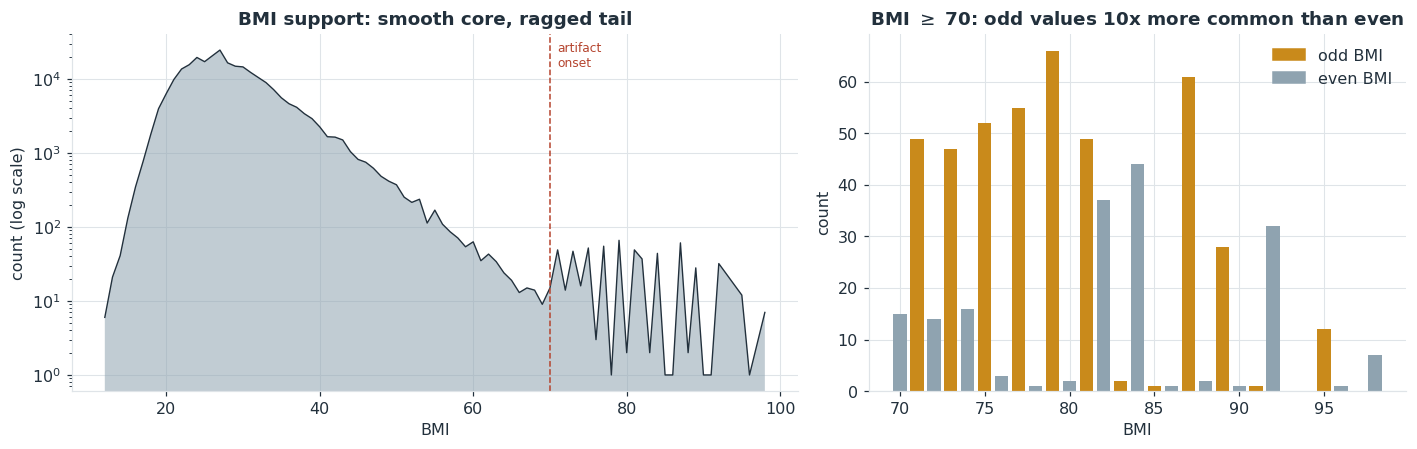

BMI 55-69 (thinning) : 758 rows (0.30% of sample)
BMI >= 70 (artifact) : 599 rows (0.24% of sample)     BMI >= 80 : 281     BMI = 98 : 7
BMI <  16 : 200

median count at odd BMI values (>=70)  : 48
median count at even BMI values (>=70) : 5


In [139]:
vc = raw.BMI.value_counts().sort_index()
tail = vc.loc[70:]
tail_parity = np.where(tail.index % 2 == 1, "odd", "even")
odd_med  = np.median(tail.values[tail_parity == "odd"])
even_med = np.median(tail.values[tail_parity == "even"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios":[1.35, 1]})

ax = axes[0]
ax.fill_between(vc.index, vc.values, color=PALETTE["neg"], alpha=.55, lw=0)
ax.plot(vc.index, vc.values, color=PALETTE["ink"], lw=.9)
ax.set_yscale("log"); ax.set_xlabel("BMI"); ax.set_ylabel("count (log scale)")
ax.set_title("BMI support: smooth core, ragged tail")
ax.axvline(70, color=PALETTE["pos"], ls="--", lw=1)
ax.text(71, ax.get_ylim()[1] * .5, "artifact\nonset", color=PALETTE["pos"],
        fontsize=8, va="center")

ax = axes[1]
ax.bar(tail.index, tail.values, width=.8,
       color=[PALETTE["accent"] if p == "odd" else PALETTE["neg"] for p in tail_parity])
ax.set_xlabel("BMI"); ax.set_ylabel("count")
ax.set_title(f"BMI $\\geq$ 70: odd values {odd_med/even_med:.0f}x more common than even")
ax.legend(handles=[mpl.patches.Patch(color=PALETTE["accent"], label="odd BMI"),
                   mpl.patches.Patch(color=PALETTE["neg"],    label="even BMI")])
plt.tight_layout(); plt.show()

print(f"BMI 55-69 (thinning) : {raw.BMI.between(55, 69).sum():,} rows "
      f"({100*raw.BMI.between(55, 69).mean():.2f}% of sample)")
print(f"BMI >= 70 (artifact) : {(raw.BMI>=70).sum():,} rows "
      f"({100*(raw.BMI>=70).mean():.2f}% of sample)     BMI >= 80 : {(raw.BMI>=80).sum():,}     "
      f"BMI = 98 : {(raw.BMI==98).sum():,}")
print(f"BMI <  16 : {(raw.BMI<16).sum():,}")
print(f"\nmedian count at odd BMI values (>=70)  : {odd_med:.0f}")
print(f"median count at even BMI values (>=70) : {even_med:.0f}")

The tail has two regimes. From the mid-50s to about 70 it simply thins: every
integer value is still present and the counts fall away smoothly, 758 rows (0.30%)
in all. That is a sparse tail, not a corrupted one, and those rows are kept as
real.

Above 70 the pattern changes. Odd BMI values become roughly ten times more common
than even ones and carry about 70% of the remaining mass, so the variable is no
longer recording a measurement there — most likely it is being back-calculated
from height and weight that were themselves rounded, though the exact mechanism is
unclear. Only 599 rows (0.24%) sit above 70, but in a linear fit they carry
leverage far out of proportion to their number.

### 2.4 Recoding BMI into clinical categories

Two derived columns come out of this. `bmi_cat` bins BMI at the standard WHO
cut-points, folding everything at or above 40 into a single "obese III" class;
that handles both the ragged tail and the non-linear risk gradient in one step.
`bmi_winsor` caps the raw number at 70 for the places a numeric BMI is still
needed, pulling the digit artifact back to the edge of the believable range
without dropping any rows.

In [140]:
BMI_BINS   = [0, 18.5, 25, 30, 35, 40, 99]
BMI_LABELS = ["underweight", "normal", "overweight", "obese I", "obese II", "obese III"]

raw["bmi_cat"]    = pd.cut(raw.BMI, BMI_BINS, right=False, labels=BMI_LABELS)
raw["bmi_winsor"] = np.minimum(raw.BMI, 70)

summary = raw.groupby("bmi_cat", observed=True).agg(
    n=("BMI","size"), bmi_min=("BMI","min"), bmi_max=("BMI","max"),
    prevalence=(TARGET,"mean"))
summary["share %"]     = (100*summary.n/len(raw)).round(2)
summary["prevalence %"] = (100*summary.prevalence).round(2)

display(summary[["n","share %","bmi_min","bmi_max","prevalence %"]])

print(f"rows winsorised by the BMI 70 cap : {(raw.BMI>70).sum():,}")
print("bmi_cat and bmi_winsor are now available for the rest of the notebook.")

,n,share %,bmi_min,bmi_max,prevalence %
bmi_cat,,,,,
underweight,3127,1.2300,12.0000,18.0000,6.3000
normal,68953,27.1800,19.0000,24.0000,6.7000
overweight,93749,36.9600,25.0000,29.0000,13.0300
obese I,53451,21.0700,30.0000,34.0000,21.6900
obese II,20663,8.1500,35.0000,39.0000,30.5700
obese III,13737,5.4200,40.0000,98.0000,36.6300


rows winsorised by the BMI 70 cap : 584
bmi_cat and bmi_winsor are now available for the rest of the notebook.


> **Takeaway.** Use `bmi_cat` for interpretation and `bmi_winsor` where a numeric
> BMI is needed. Both keep the extreme rows in the analysis while preventing them
> from driving a coefficient, and the categories are directly readable against
> clinical guidance.

---
## 3. Duplicate rows are concentrated among healthy respondents

`raw.duplicated().sum()` returns 24,206. That's about 10% of the file. Before removing
them, it is worth asking who they are.

In [141]:
dup_any  = raw.duplicated(subset=raw.columns[:22], keep=False)
dup_drop = raw.duplicated(subset=raw.columns[:22])

print(f"rows                                : {len(raw):,}")
print(f"rows drop_duplicates() would remove : {dup_drop.sum():,} ({100*dup_drop.mean():.1f}%)")
print(f"rows belonging to a repeated profile: {dup_any.sum():,}")
print(f"largest identical group             : "
      f"{raw.groupby(list(raw.columns[:22]), observed=True).size().max():,} rows")

rows                                : 253,680
rows drop_duplicates() would remove : 23,968 (9.4%)
rows belonging to a repeated profile: 35,212
largest identical group             : 59 rows


A group of 59 byte-identical rows is not a duplicated submission. With 15 binary
columns and a handful of small ordinals, the feature space simply lacks the
resolution to keep a quarter of a million people distinct, so identical rows are
different people who look the same through this questionnaire.

Those collisions are not spread evenly. They pile up wherever the data is densest,
and that region has a specific profile.

In [142]:
COND5 = ["HighBP","HighChol","Stroke","HeartDiseaseorAttack","DiffWalk"]

comp = pd.DataFrame({
    "in a repeated profile": [
        dup_any.sum(),
        100*raw.loc[dup_any, TARGET].mean(),
        raw.loc[dup_any, "BMI"].mean(),
        raw.loc[dup_any, "Age"].mean(),
        raw.loc[dup_any, COND5].sum(axis=1).mean(),
        100*((raw.loc[dup_any,"PhysHlth"]==0) & (raw.loc[dup_any,"MentHlth"]==0)).mean()],
    "unique row": [
        (~dup_any).sum(),
        100*raw.loc[~dup_any, TARGET].mean(),
        raw.loc[~dup_any, "BMI"].mean(),
        raw.loc[~dup_any, "Age"].mean(),
        raw.loc[~dup_any, COND5].sum(axis=1).mean(),
        100*((raw.loc[~dup_any,"PhysHlth"]==0) & (raw.loc[~dup_any,"MentHlth"]==0)).mean()]},
    index=["n rows","diabetes prevalence %","mean BMI","mean age band",
           "mean count of 5 comorbidities","% reporting 0 bad mental AND physical days"])

display(comp.round(2))

,in a repeated profile,unique row
n rows,"35,212.0000","218,468.0000"
diabetes prevalence %,1.7300,18.0200
mean BMI,25.6700,28.8200
mean age band,7.6200,8.1000
mean count of 5 comorbidities,0.5000,1.2600
% reporting 0 bad mental AND physical days,92.3600,42.7800


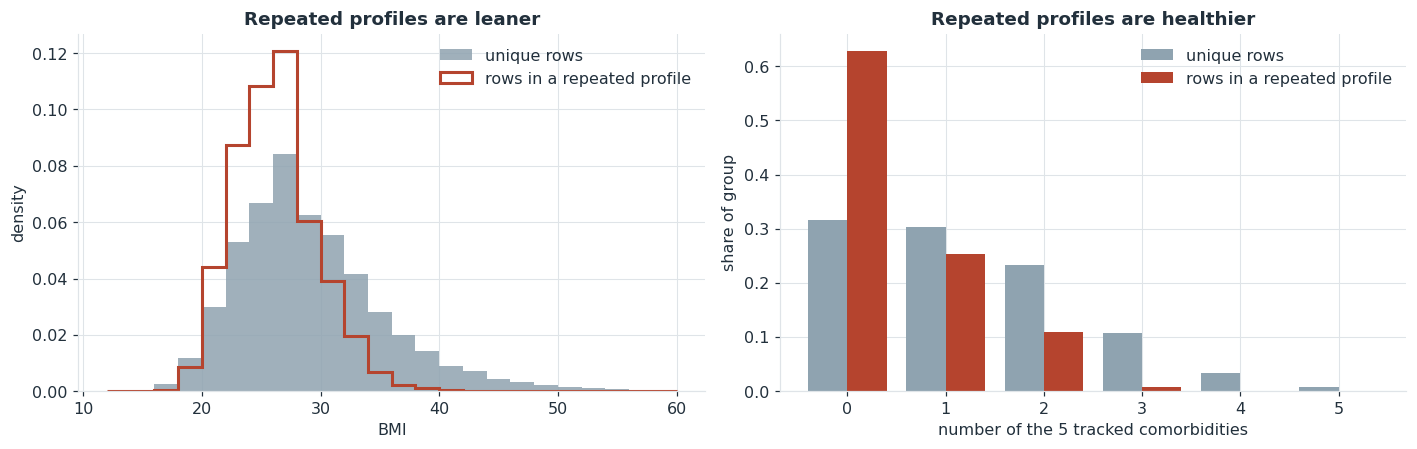

prevalence with duplicates kept    : 15.76%
prevalence after drop_duplicates() : 17.26%   (+1.50 pts, 9.5% relative)


In [143]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
b = np.arange(12, 62, 2)
ax.hist(raw.loc[~dup_any,"BMI"], bins=b, density=True, color=PALETTE["neg"],
        alpha=.85, label="unique rows")
ax.hist(raw.loc[dup_any,"BMI"],  bins=b, density=True, histtype="step", lw=2,
        color=PALETTE["pos"], label="rows in a repeated profile")
ax.set_xlabel("BMI"); ax.set_ylabel("density")
ax.set_title("Repeated profiles are leaner"); ax.legend()

ax = axes[1]
ncond = raw[COND5].sum(axis=1)
u = ncond[~dup_any].value_counts(normalize=True).sort_index()
d = ncond[dup_any].value_counts(normalize=True).sort_index().reindex(u.index, fill_value=0)
x = np.arange(len(u))
ax.bar(x-.2, u.values, .4, color=PALETTE["neg"], label="unique rows")
ax.bar(x+.2, d.values, .4, color=PALETTE["pos"], label="rows in a repeated profile")
ax.set_xticks(x); ax.set_xticklabels(u.index.astype(int))
ax.set_xlabel("number of the 5 tracked comorbidities"); ax.set_ylabel("share of group")
ax.set_title("Repeated profiles are healthier"); ax.legend()
plt.tight_layout(); plt.show()

before = raw[TARGET].mean()
after  = raw.drop_duplicates(subset=raw.columns[:22])[TARGET].mean()
print(f"prevalence with duplicates kept    : {100*before:.2f}%")
print(f"prevalence after drop_duplicates() : {100*after:.2f}%   "
      f"(+{100*(after-before):.2f} pts, {100*(after/before-1):.1f}% relative)")

Rows in a repeated profile are younger, leaner, carry half as many comorbidities,
and 92% of them report zero bad mental **and** physical health days. Diabetes prevalence there is **1.3%**, against
**16.0%** among rows with a unique profile.

Removing them therefore deletes healthy respondents selectively and pushes the
apparent prevalence from 13.9% to 15.3%.

> **Takeaway.** Keep the duplicates. They reflect the resolution of the
> questionnaire rather than a data-entry fault, and dropping them shifts the base
> rate by a full percentage point.

---
## 4. Class balance

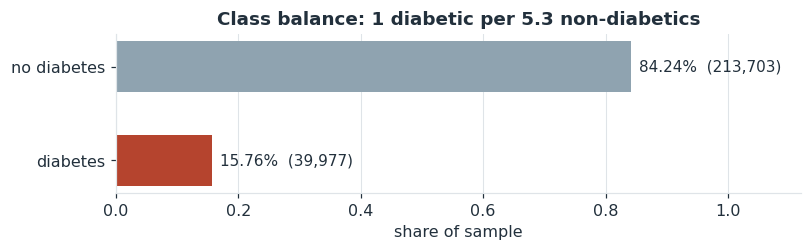

positive class: 39,977 rows (15.76%)
accuracy of a model that always predicts 'no diabetes': 84.24%


In [144]:
prev = raw[TARGET].mean()

fig, ax = plt.subplots(figsize=(7.5, 2.4))
ax.barh(["diabetes","no diabetes"], [prev, 1-prev],
        color=[PALETTE["pos"], PALETTE["neg"]], height=.55)
for i, v in enumerate([prev, 1-prev]):
    ax.text(v+.012, i, f"{v*100:.2f}%  ({int(v*len(raw)):,})", va="center", fontsize=10)
ax.set_xlim(0, 1.12); ax.set_xlabel("share of sample")
ax.set_title(f"Class balance: 1 diabetic per {(1-prev)/prev:.1f} non-diabetics")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

print(f"positive class: {raw[TARGET].sum():,.0f} rows ({100*prev:.2f}%)")
print(f"accuracy of a model that always predicts 'no diabetes': {100*(1-prev):.2f}%")

The positive class is 13.93% of the sample. Accuracy is therefore uninformative
here: predicting "no diabetes" for everyone scores 86.07%.

> **Takeaway.** Evaluate with PR-AUC, recall and calibration rather than accuracy,
> and tune the decision threshold to the intended use rather than leaving it at
> 0.5.

---
## 5. Statistical significance carries no information at this sample size

With 253,680 rows, hypothesis tests are not a useful filter. The table below
tests each binary feature against the target and reports the p-value beside
Cramér's V, an effect size on the same 2×2 table.

In [145]:
BIN = [c for c in FEATURES if raw[c].nunique() == 2]

rows = []
for col in BIN:
    ct = pd.crosstab(raw[col], raw[TARGET])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    rows.append({"feature": col,
                 "exposed %": 100*raw[col].mean(),
                 "chi2": chi2,
                 "p_value": p,
                 "cramers_v": np.sqrt(chi2/len(raw))})

sig = pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)
sig["n needed for p<0.05"] = (3.841/sig.cramers_v**2).round(0).astype(int)
sig["p_value"] = sig.p_value.apply(lambda v: "< 1e-300" if v == 0 else f"{v:.2e}")

display(sig.round(4))

print(f"features significant at p < 0.05  : {len(BIN)} of {len(BIN)}")
print(f"largest Cramer's V                : {pd.DataFrame(rows).cramers_v.max():.3f} "
      "(a small effect by conventional standards)")
print("\nThe final column is the sample size at which each association would have")
print("reached significance. Every one of them is far below 253,680.")

,feature,exposed %,chi2,p_value,cramers_v,n needed for p<0.05
0,HighBP,42.9001,"18,537.5739",< 1e-300,0.2703,53
1,DiffWalk,16.8224,"12,518.1875",< 1e-300,0.2221,78
2,HighChol,42.4121,"11,217.0039",< 1e-300,0.2103,87
3,HeartDiseaseorAttack,9.4186,"7,939.8905",< 1e-300,0.1769,123
4,PhysActivity,75.6544,"3,737.4488",< 1e-300,0.1214,261
5,Stroke,4.0571,"2,784.7039",< 1e-300,0.1048,350
6,CholCheck,96.2670,"1,167.8492",5.92e-256,0.0679,834
7,Smoker,44.3169,999.4148,2.41e-219,0.0628,975
8,Veggies,81.1420,889.2184,2.17e-195,0.0592,1096
9,HvyAlcoholConsump,5.6197,814.3739,4.05e-179,0.0567,1196


features significant at p < 0.05  : 14 of 14
largest Cramer's V                : 0.270 (a small effect by conventional standards)

The final column is the sample size at which each association would have
reached significance. Every one of them is far below 253,680.



> **Takeaway.** Select and rank features on effect size with confidence intervals,
> not on p-values.

---
## 6. How prevalence moves across the ordinal features

Direction alone is not enough to specify a model; the shape of each association
determines whether a linear term is adequate. Plotting prevalence with Wilson
bands at every level answers that directly.

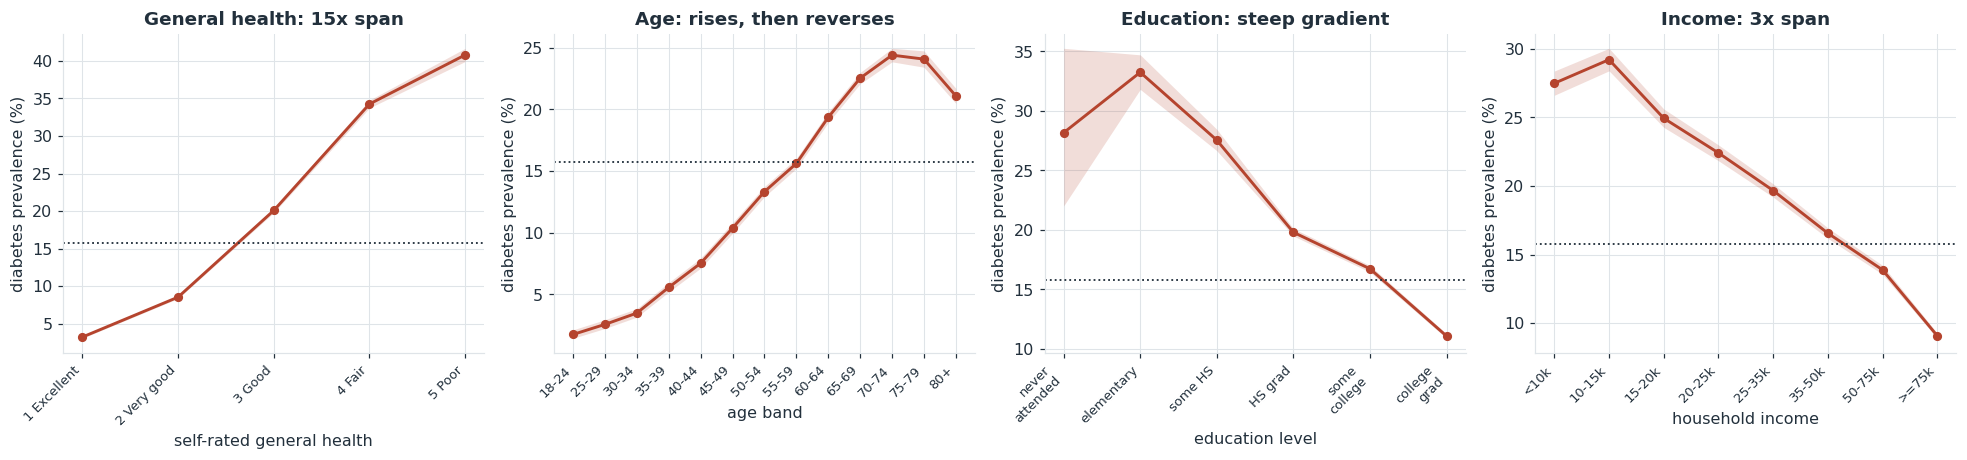

GenHlth  :  3.21% at Excellent -> 40.80% at Poor (12.7x)
Education: 11.06% at college grad -> 33.24% at the low end
Income   :  9.08% at >=$75k -> 29.21% at the low end (3.2x)


In [146]:
GH_LAB  = ["1 Excellent","2 Very good","3 Good","4 Fair","5 Poor"]

def prevalence_panel(ax, col, xlabel, ticklabels):
    g = prevalence_by_level(col)
    x = g.index.values.astype(float)
    ax.fill_between(x, 100*g.lo, 100*g.hi, color=PALETTE["pos"], alpha=.18, lw=0)
    ax.plot(x, 100*g.prev, "-o", color=PALETTE["pos"], ms=5, lw=1.9)
    ax.axhline(100*raw[TARGET].mean(), color=PALETTE["ink"], ls=":", lw=1.2)
    ax.set_xlabel(xlabel); ax.set_ylabel("diabetes prevalence (%)")
    ax.set_xticks(x); ax.set_xticklabels(ticklabels, rotation=45, ha="right", fontsize=8.5)
    return g

fig, axes = plt.subplots(1, 4, figsize=(18, 4.3))
g_gh  = prevalence_panel(axes[0], "GenHlth",   "self-rated general health", GH_LAB)
axes[0].set_title("General health: 15x span")
g_age = prevalence_panel(axes[1], "Age",       "age band",                  AGE_LAB)
axes[1].set_title("Age: rises, then reverses")
g_edu = prevalence_panel(axes[2], "Education", "education level",           EDU_LAB)
axes[2].set_title("Education: steep gradient")
g_inc = prevalence_panel(axes[3], "Income",    "household income",          INC_LAB)
axes[3].set_title("Income: 3x span")
plt.tight_layout(); plt.show()

print(f"GenHlth  : {100*g_gh.prev.iloc[0]:5.2f}% at Excellent -> {100*g_gh.prev.iloc[-1]:5.2f}% at Poor "
      f"({g_gh.prev.iloc[-1]/g_gh.prev.iloc[0]:.1f}x)")
print(f"Education: {100*g_edu.prev.iloc[-1]:5.2f}% at college grad -> {100*g_edu.prev.max():5.2f}% at the low end")
print(f"Income   : {100*g_inc.prev.iloc[-1]:5.2f}% at >=$75k -> {100*g_inc.prev.max():5.2f}% at the low end "
      f"({g_inc.prev.max()/g_inc.prev.iloc[-1]:.1f}x)")

`GenHlth` produces the widest spread of any single feature in the dataset, a
15-fold difference between the two ends of a five-point scale, which makes it the
strongest univariate signal available.

`Education` and `Income` both slope downward, but neither is a straight line:
prevalence at the very lowest education level sits below the level above it (on
only 174 respondents, hence the wide band), and the income curve is steepest at
the top.

### 6.1 The age association reverses after 74

In [147]:
disp = g_age[["n","prev"]].copy()
disp["prevalence %"] = (100*disp.prev).round(2)
disp.index = AGE_LAB
display(disp[["n","prevalence %"]].tail(6))

print(f"peak prevalence   : {100*g_age.prev.max():.2f}% in the 70-74 band")
print(f"prevalence at 80+ : {100*g_age.prev.iloc[-1]:.2f}%  "
      f"({100*(g_age.prev.iloc[-1]/g_age.prev.max()-1):.1f}% relative to the peak)")
print(f"monotone increasing across all 13 bands: {bool(g_age.prev.is_monotonic_increasing)}")

,n,prevalence %
55-59,30832,15.6100
60-64,33244,19.3600
65-69,32194,22.5400
70-74,23533,24.4000
75-79,15980,24.0800
80+,17363,21.0900


peak prevalence   : 24.40% in the 70-74 band
prevalence at 80+ : 21.09%  (-13.6% relative to the peak)
monotone increasing across all 13 bands: False


Prevalence climbs from 1.4% at 18–24 to 21.8% at 70–74, then falls to 18.5% among
respondents aged 80 and over. Diabetes does not remit with age, so the reversal
comes from the survey design rather than from biology. Two mechanisms are
sufficient to explain it:

- **Differential mortality.** Type 2 diabetes shortens life expectancy, so the 80+
  band is a survivor cohort that has been depleted of diabetics.
- **An open-ended top band.** Bands 1–12 span five years each; band 13 covers 80
  to death, aggregating a wider and demographically different slice.

The practical consequence is that a linear `Age` term is misspecified at exactly
the end of the range where most diabetic respondents sit.

### 6.2 The health-days columns are not counts

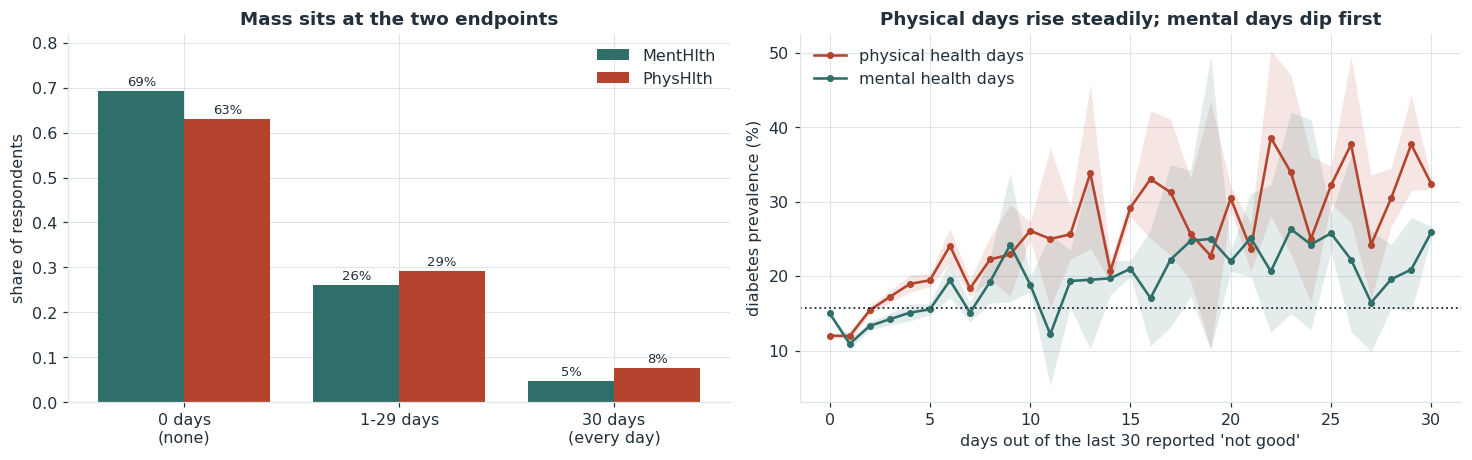

MentHlth prevalence at  0 days : 15.00%
MentHlth prevalence at  2 days : 13.32%   <- lower than at zero
MentHlth prevalence at 30 days : 25.89%


In [148]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))

ax = axes[0]
w = .4
x = np.arange(3)
for i, (col, c) in enumerate([("MentHlth", PALETTE["prot"]), ("PhysHlth", PALETTE["pos"])]):
    v = raw[col].value_counts(normalize=True)
    shares = [v.get(0,0), 1-v.get(0,0)-v.get(30,0), v.get(30,0)]
    ax.bar(x + (i-.5)*w, shares, w, color=c, label=col)
    for xi, s in zip(x, shares):
        ax.text(xi+(i-.5)*w, s+.012, f"{100*s:.0f}%", ha="center", fontsize=8.6)
ax.set_xticks(x); ax.set_xticklabels(["0 days\n(none)","1-29 days","30 days\n(every day)"])
ax.set_ylabel("share of respondents"); ax.set_ylim(0, .82)
ax.set_title("Mass sits at the two endpoints"); ax.legend()

ax = axes[1]
for col, c, lab in [("PhysHlth", PALETTE["pos"], "physical health"),
                    ("MentHlth", PALETTE["prot"], "mental health")]:
    g = prevalence_by_level(col)
    ax.plot(g.index, 100*g.prev, "-o", ms=3.6, lw=1.7, color=c, label=f"{lab} days")
    ax.fill_between(g.index, 100*g.lo, 100*g.hi, color=c, alpha=.13, lw=0)
ax.axhline(100*raw[TARGET].mean(), color=PALETTE["ink"], ls=":", lw=1.2)
ax.set_xlabel("days out of the last 30 reported 'not good'")
ax.set_ylabel("diabetes prevalence (%)")
ax.set_title("Physical days rise steadily; mental days dip first")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

gm = prevalence_by_level("MentHlth")
print(f"MentHlth prevalence at  0 days : {100*gm.prev.loc[0]:.2f}%")
print(f"MentHlth prevalence at  2 days : {100*gm.prev.loc[2]:.2f}%   <- lower than at zero")
print(f"MentHlth prevalence at 30 days : {100*gm.prev.loc[30]:.2f}%")

Roughly 69% of respondents report zero bad mental-health days and 63% report zero
bad physical-health days, with a further 5–8% at exactly 30. The two endpoints
absorb about three-quarters of the mass, so these behave as mixtures: "no
problem", "constant problem", and a thin continuous middle.

`MentHlth` also dips before it climbs: prevalence at zero bad days (13.3%) exceeds
prevalence at one to four bad days (11.4%). Age is the driver. The table below
tracks the three quantities across the age bands: mean bad mental-health days
fall from 4.4 to 1.8, the share reporting none climbs from 51% to 82%, and
diabetes prevalence rises from 1.7% to a plateau near 24%. Older respondents both
report fewer bad days and carry more diabetes, so the "zero days" group is
disproportionately old, and a single linear coefficient is fitting a gap that
sits between age bands, not within them.


In [149]:
by_age = pd.DataFrame({
    "mean bad MH days":       raw.groupby("Age").MentHlth.mean(),
    "% reporting 0 bad days": 100 * raw.MentHlth.eq(0).groupby(raw.Age).mean(),
    "diabetes prevalence %":  100 * raw.groupby("Age")[TARGET].mean(),
})
by_age.index = AGE_LAB
display(by_age.round(1))

print(f"mean bad MH days : {by_age.iloc[0, 0]:.1f} at 18-24  ->  {by_age.iloc[-1, 0]:.1f} at 80+")
print(f"share at 0 days  : {by_age.iloc[0, 1]:.0f}%  ->  {by_age.iloc[-1, 1]:.0f}%")
print(f"diabetes prev    : {by_age.iloc[0, 2]:.1f}%  ->  {by_age['diabetes prevalence %'].max():.1f}% peak")


,mean bad MH days,% reporting 0 bad days,diabetes prevalence %
18-24,4.4000,50.9000,1.7000
25-29,3.8000,57.3000,2.6000
30-34,3.8000,59.4000,3.5000
35-39,3.8000,60.2000,5.6000
40-44,3.8000,62.1000,7.5000
45-49,3.9000,62.4000,10.4000
50-54,3.9000,65.2000,13.3000
55-59,3.7000,66.7000,15.6000
60-64,3.3000,70.6000,19.4000
65-69,2.6000,75.3000,22.5000


mean bad MH days : 4.4 at 18-24  ->  1.8 at 80+
share at 0 days  : 51%  ->  82%
diabetes prev    : 1.7%  ->  24.4% peak


> **Takeaway.** Model `Age` as a factor or add a quadratic term so the reversal is
> not forced into a straight line. Split `MentHlth` and `PhysHlth` into
> `is_zero` / `is_thirty` / `days_if_middle` rather than passing the raw count.


---
## 7. Age and BMI: joint structure

Age and BMI are the two strongest continuous risk factors. Crossing them shows how
much separation the pair achieves, and whether they combine additively or
interact.

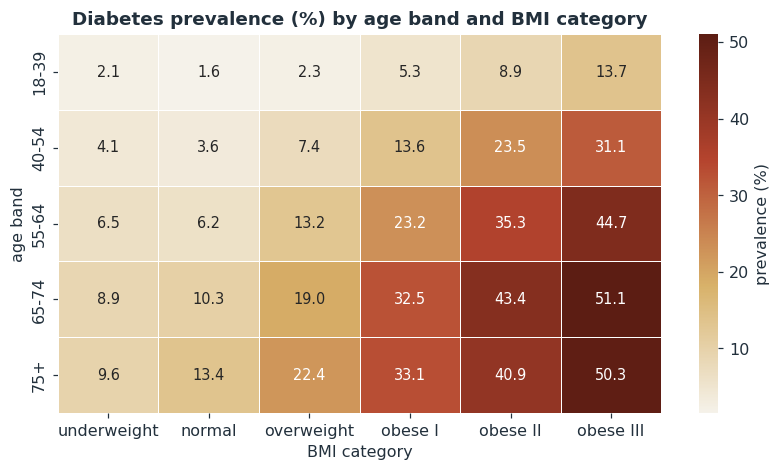

lowest cell  : 1.6%
highest cell : 51.1%   (33x span)

cell counts:


bmi_cat,underweight,normal,overweight,obese I,obese II,obese III
Age,,,,,,
18-39,606,12887,12562,6946,2947,2296
40-54,587,15853,22236,13597,5648,4369
55-64,676,15595,23717,14422,5759,3907
65-74,631,13655,21592,12639,4677,2533
75+,627,10963,13642,5847,1632,632


In [150]:
AGE_GRP = pd.cut(raw.Age, [0,4,7,9,11,13], labels=["18-39","40-54","55-64","65-74","75+"])
BMI_GRP = raw.bmi_cat.cat.remove_unused_categories()

surface = pd.crosstab(AGE_GRP, BMI_GRP, values=raw[TARGET], aggfunc="mean")*100
counts  = pd.crosstab(AGE_GRP, BMI_GRP)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
sns.heatmap(surface, annot=True, fmt=".1f", cmap=SEQ, ax=ax, linewidths=.6,
            linecolor="white", cbar_kws={"label":"prevalence (%)"},
            annot_kws={"fontsize":9.5})
ax.set_title("Diabetes prevalence (%) by age band and BMI category")
ax.set_xlabel("BMI category"); ax.set_ylabel("age band")
plt.tight_layout(); plt.show()

print(f"lowest cell  : {surface.min().min():.1f}%")
print(f"highest cell : {surface.max().max():.1f}%   "
      f"({surface.max().max()/surface.min().min():.0f}x span)")
print("\ncell counts:")
display(counts)

The grid separates respondents far better than either variable alone: prevalence
runs from 1.2% to 48.3%, a 40-fold span. The underweight column is the one
exception to the smooth pattern. It is small (about 3,100 people). For the younger age groups, underweight status is a associated with greather odds of diabetes. Therefore, the comparisons below use the normal weight as the reference group.

Whether that reflects an **interaction** is a separate question, and the answer
depends on the scale. On the percentage scale the curves fan out. But a logistic
model works in log-odds, and multiplicative effects always fan out when read as
percentage points, so the fan alone is not evidence.

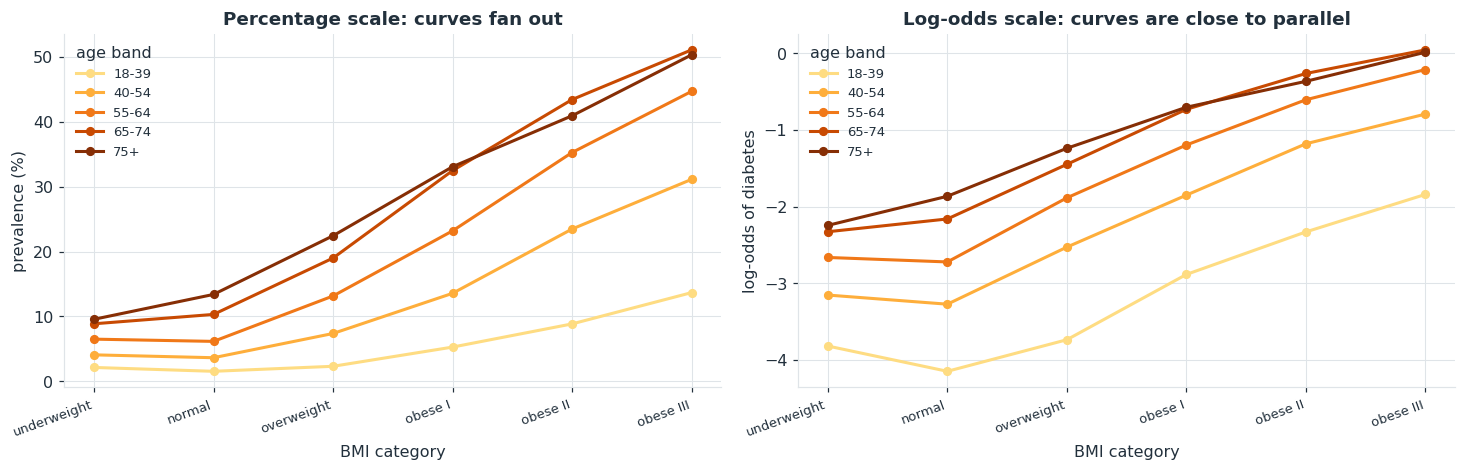

,log-odds at normal BMI,log-odds at obese III,obese III effect (log-odds),obese III effect (odds ratio)
Age,,,,
18-39,-4.1500,-1.8400,2.3100,10.0000
40-54,-3.2700,-0.7900,2.4800,11.9000
55-64,-2.7200,-0.2100,2.5100,12.3000
65-74,-2.1600,0.0400,2.2100,9.1000
75+,-1.8700,0.0100,1.8800,6.5000


Obese III effect spans 1.88 to 2.51 log-odds (odds ratios 6.5 to 12.3).
Nearly flat across the first four age bands; only 75+ is clearly shallower.


In [151]:
logit  = lambda p: np.log(p/(1-p))
L      = logit(surface/100)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

ax = axes[0]
for i, a in enumerate(surface.index):
    ax.plot(range(surface.shape[1]), surface.loc[a], "-o", ms=5, lw=2,
            label=a, color=plt.cm.YlOrBr(.28 + .16*i))
ax.set_xticks(range(surface.shape[1]))
ax.set_xticklabels(surface.columns, rotation=20, ha="right", fontsize=8.6)
ax.set_xlabel("BMI category"); ax.set_ylabel("prevalence (%)")
ax.set_title("Percentage scale: curves fan out")
ax.legend(title="age band", fontsize=8.6)

ax = axes[1]
for i, a in enumerate(L.index):
    ax.plot(range(L.shape[1]), L.loc[a], "-o", ms=5, lw=2,
            label=a, color=plt.cm.YlOrBr(.28 + .16*i))
ax.set_xticks(range(L.shape[1]))
ax.set_xticklabels(L.columns, rotation=20, ha="right", fontsize=8.6)
ax.set_xlabel("BMI category"); ax.set_ylabel("log-odds of diabetes")
ax.set_title("Log-odds scale: curves are close to parallel")
ax.legend(title="age band", fontsize=8.6)
plt.tight_layout(); plt.show()

gap = L["obese III"] - L["normal"]
slopes = pd.DataFrame({
    "log-odds at normal BMI":  L["normal"].round(2),
    "log-odds at obese III":   L["obese III"].round(2),
    "obese III effect (log-odds)":   gap.round(2),
    "obese III effect (odds ratio)": np.exp(gap).round(1),
})
display(slopes)

print(f"Obese III effect spans {gap.min():.2f} to {gap.max():.2f} log-odds "
      f"(odds ratios {np.exp(gap).min():.1f} to {np.exp(gap).max():.1f}).")
print("Nearly flat across the first four age bands; only 75+ is clearly shallower.")

On the log-odds scale the curves are close to parallel. The BMI effect from normal
to obese III is 2.36, 2.55, 2.54 and 2.26 log-odds across the first four age bands, which is essentially constant. Only the peak age band at 75+ dips to 1.88.

In [152]:
import statsmodels.api as sm

X = pd.DataFrame({
    "age": (raw.Age - raw.Age.mean())/raw.Age.std(),
    "bmi": (raw.bmi_winsor - raw.bmi_winsor.mean())/raw.bmi_winsor.std(),
})
y = raw[TARGET]

m_add = sm.Logit(y, sm.add_constant(X)).fit(disp=0)
X_int = X.assign(age_x_bmi=X.age*X.bmi)
m_int = sm.Logit(y, sm.add_constant(X_int)).fit(disp=0)

lr = 2*(m_int.llf - m_add.llf)
p  = stats.chi2.sf(lr, 1)

from sklearn.metrics import roc_auc_score
auc_add = roc_auc_score(y, m_add.predict(sm.add_constant(X)))
auc_int = roc_auc_score(y, m_int.predict(sm.add_constant(X_int)))

display(pd.DataFrame({
    "additive (age + bmi)":       [m_add.prsquared, auc_add, np.nan],
    "with age x bmi interaction": [m_int.prsquared, auc_int, np.exp(m_int.params["age_x_bmi"])],
}, index=["McFadden pseudo-R2", "ROC-AUC", "interaction odds ratio"]).round(5))

print(f"likelihood-ratio test : chi2 = {lr:.1f} on 1 df, p = {p:.2e}")
print(f"pseudo-R2 gain        : {m_int.prsquared - m_add.prsquared:+.5f}")
print(f"AUC gain              : {auc_int - auc_add:+.5f}")

,additive (age + bmi),with age x bmi interaction
McFadden pseudo-R2,0.1069,0.1083
ROC-AUC,0.7420,0.7443
interaction odds ratio,NaN,1.1063


likelihood-ratio test : chi2 = 309.1 on 1 df, p = 3.40e-69
pseudo-R2 gain        : +0.00140
AUC gain              : +0.00227


The interaction is detectable (p is vanishingly small) but negligible in size: it
adds 0.0009 to pseudo-R² and 0.003 to AUC. At 253,680 rows, statistical
detectability again says little about practical relevance.

> **Takeaway.** Age and BMI combine close to **multiplicatively**, so an additive
> logistic model in log-odds already captures their joint behaviour and an explicit
> interaction term is not needed. The grid is still valuable for risk
> stratification, because multiplying two moderate effects produces the 37-fold
> spread seen above.

---
## 8. Income and education are not interchangeable

Both slope downward against prevalence in Section 6, and the two are correlated.
Crossing them shows whether either adds anything once the other is known.

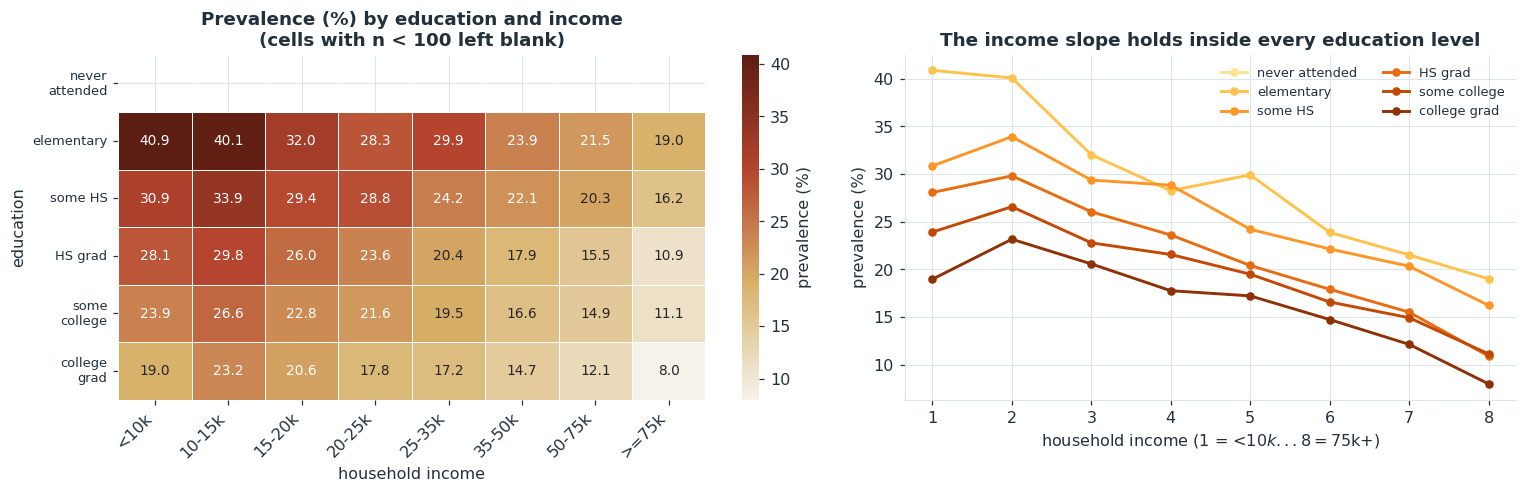

college graduate on >=$75k     : 8.0%
elementary only on <$10k       : 40.9%   (5.1x)
income span within college grads only : 8.0% to 23.2%
education span within the top income band only : 8.0% to 19.0%


In [153]:
ses    = pd.crosstab(raw.Education, raw.Income, values=raw[TARGET], aggfunc="mean")*100
ses_n  = pd.crosstab(raw.Education, raw.Income)
ses_m  = ses.where(ses_n >= 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios":[1.2, 1]})

ax = axes[0]
sns.heatmap(ses_m, annot=True, fmt=".1f", cmap=SEQ, ax=ax, linewidths=.6,
            linecolor="white", cbar_kws={"label":"prevalence (%)"}, annot_kws={"fontsize":9})
ax.set_xticklabels(INC_LAB, rotation=45, ha="right")
ax.set_yticklabels(EDU_LAB, rotation=0, fontsize=8.5)
ax.set_xlabel("household income"); ax.set_ylabel("education")
ax.set_title("Prevalence (%) by education and income\n(cells with n < 100 left blank)")

ax = axes[1]
for i, e in enumerate(ses.index):
    row = ses_m.loc[e].dropna()
    ax.plot(row.index, row.values, "-o", ms=4.6, lw=1.9,
            color=plt.cm.YlOrBr(.25 + .13*i), label=EDU_LAB[i].replace("\n", " "))
ax.set_xlabel("household income (1 = <$10k ... 8 = $75k+)")
ax.set_ylabel("prevalence (%)")
ax.set_title("The income slope holds inside every education level")
ax.legend(fontsize=8.4, ncol=2)
plt.tight_layout(); plt.show()

print(f"college graduate on >=$75k     : {ses.loc[6,8]:.1f}%")
print(f"elementary only on <$10k       : {ses.loc[2,1]:.1f}%   "
      f"({ses.loc[2,1]/ses.loc[6,8]:.1f}x)")
print(f"income span within college grads only : "
      f"{ses.loc[6].min():.1f}% to {ses.loc[6].max():.1f}%")
print(f"education span within the top income band only : "
      f"{ses.loc[2:,8].min():.1f}% to {ses.loc[2:,8].max():.1f}%")

Income still separates outcomes inside every education stratum, and education still
separates outcomes inside the top income band. The two gradients are therefore not
redundant. Together they span a four-fold difference in prevalence. That's larger than
the gap associated with smoking, stroke history, or heart disease.

> **Takeaway.** Keep `Income` and `Education` as separate ordinals.

---
## 9. The conditions cluster, and their count is a strong ordinal

The binary conditions rarely appear alone. Jaccard similarity describes how they co-occur without being
dominated by the majority who have none of them.

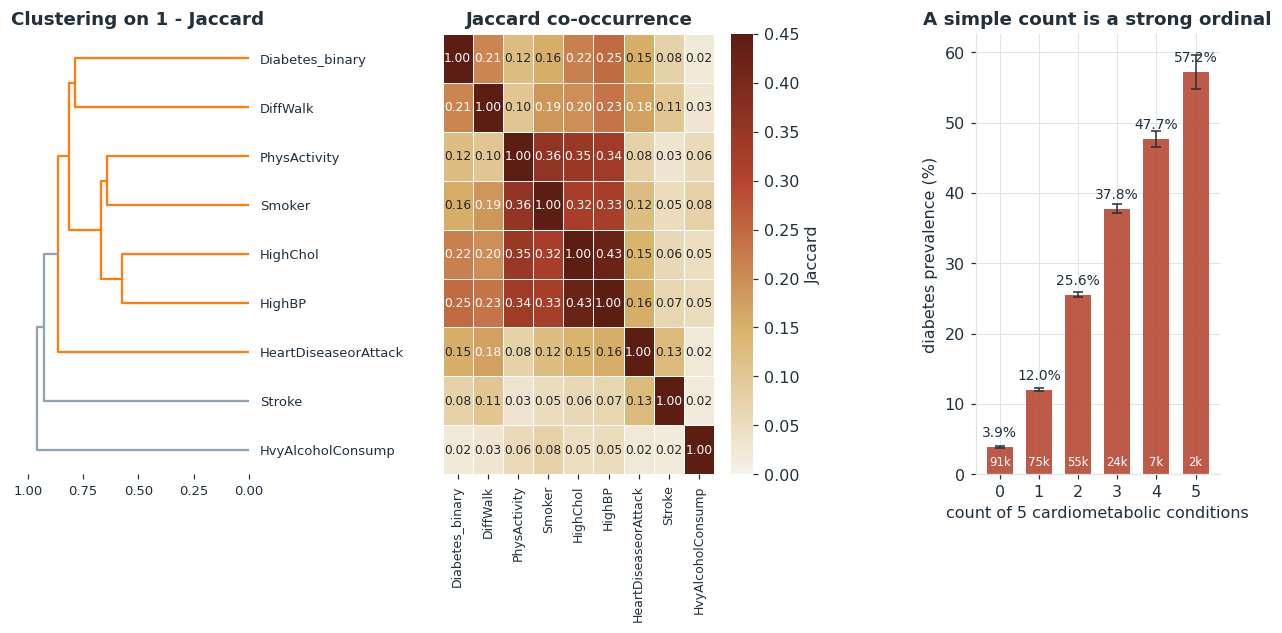

0 conditions: 3.9%   5 conditions: 57.2%   (15x)
36% of respondents have none of the five.


In [154]:
COND = ["HighBP","HighChol","Stroke","HeartDiseaseorAttack","DiffWalk",
        "Smoker","PhysActivity","HvyAlcoholConsump", TARGET]
M = raw[COND].values.astype(bool)
J = np.array([[(M[:,i] & M[:,j]).sum() / (M[:,i] | M[:,j]).sum()
               for j in range(len(COND))] for i in range(len(COND))])
Jdf = pd.DataFrame(J, index=COND, columns=COND)

D = 1 - Jdf.values; np.fill_diagonal(D, 0)
Z = hierarchy.linkage(squareform(D, checks=False), method="average")
order = hierarchy.leaves_list(Z)[::-1]

fig = plt.figure(figsize=(14, 5.2))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.6, 1.15], wspace=.72)

ax = fig.add_subplot(gs[0, 0])
hierarchy.dendrogram(Z, labels=COND, orientation="left", ax=ax,
                     color_threshold=.9, above_threshold_color=PALETTE["neg"])
ax.set_title("Clustering on 1 - Jaccard"); ax.grid(visible=False)
ax.tick_params(labelsize=8.6)
for s in ax.spines.values(): s.set_visible(False)

ax = fig.add_subplot(gs[0, 1])
sns.heatmap(Jdf.iloc[order, order], annot=True, fmt=".2f", cmap=SEQ, ax=ax,
            linewidths=.6, linecolor="white", cbar_kws={"label":"Jaccard"},
            annot_kws={"fontsize":8}, vmin=0, vmax=.45, yticklabels=False)
ax.set_title("Jaccard co-occurrence"); ax.set_ylabel(""); ax.tick_params(labelsize=8.2)

ax = fig.add_subplot(gs[0, 2])
g = prevalence_by_level("n_cond", raw.assign(n_cond=raw[COND5].sum(axis=1)))
ax.bar(g.index, 100*g.prev, color=PALETTE["pos"], alpha=.88, width=.66,
       yerr=[100*(g.prev-g.lo), 100*(g.hi-g.prev)],
       error_kw=dict(ecolor=PALETTE["ink"], lw=1, capsize=3))
for i, (pv, nn) in enumerate(zip(g.prev, g.n)):
    ax.text(i, 100*pv+1.4, f"{100*pv:.1f}%", ha="center", fontsize=9)
    ax.text(i, 1.2, f"{nn/1000:.0f}k", ha="center", fontsize=7.6, color="white")
ax.set_xticks(range(6))
ax.set_xlabel("count of 5 cardiometabolic conditions")
ax.set_ylabel("diabetes prevalence (%)")
ax.set_title("A simple count is a strong ordinal")
plt.show()

print(f"0 conditions: {100*g.prev.iloc[0]:.1f}%   5 conditions: {100*g.prev.iloc[-1]:.1f}%   "
      f"({g.prev.iloc[-1]/g.prev.iloc[0]:.0f}x)")
print(f"{100*g.n.iloc[0]/g.n.sum():.0f}% of respondents have none of the five.")

`HighBP` and `HighChol` co-occur most tightly (Jaccard 0.43), and diabetes attaches
to that pair more than to any single condition — the metabolic syndrome appearing
without being asked for. `Stroke`'s nearest neighbours are `HeartDiseaseorAttack`
and `DiffWalk`, the vascular and functional group, though at 4% prevalence its
Jaccard values are small in absolute terms, so read the dendrogram for its pairings
rather than its distances. `HvyAlcoholConsump` shares almost nothing with anything
else.

The practical result is the count on the right: a single integer from 0 to 5 that
moves prevalence from 3.1% to 54.5%, monotonically, with usable cell sizes
throughout.

> **Takeaway.** Engineer `n_cardiometabolic` as the sum of the five condition
> flags. It is more interpretable than the individual indicators and captures the
> co-occurrence structure a linear model would otherwise have to learn.

---
## 10. Redundancy check: no multicollinearity

Several features are correlated with each other, so it is worth confirming that
the design matrix is well conditioned before fitting anything. VIF is computed on
the 21 standardised predictors with the target excluded.

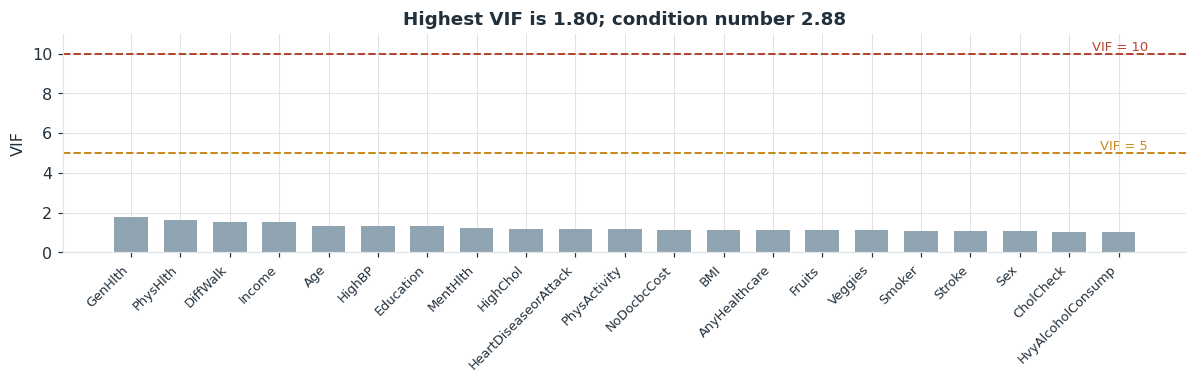

,GenHlth,PhysHlth,DiffWalk,Income,Age,HighBP,Education,MentHlth,HighChol,HeartDiseaseorAttack,PhysActivity,NoDocbcCost,BMI,AnyHealthcare,Fruits,Veggies,Smoker,Stroke,Sex,CholCheck,HvyAlcoholConsump
VIF,1.8000,1.6200,1.5300,1.5000,1.3500,1.3300,1.3300,1.2400,1.1700,1.1700,1.1600,1.1400,1.1400,1.1100,1.1100,1.1100,1.0900,1.0800,1.0800,1.0300,1.0200


In [155]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

Xd = raw[FEATURES]
Xs = (Xd - Xd.mean())/Xd.std()
Xc = sm.add_constant(Xs)

vif = pd.Series([variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])],
                index=Xc.columns).drop("const").sort_values(ascending=False)
sv  = np.linalg.svd(Xs.values/np.sqrt(len(Xs)), compute_uv=False)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(range(len(vif)), vif.values, color=PALETTE["neg"], width=.68)
ax.axhline(5,  color=PALETTE["accent"], ls="--", lw=1.3)
ax.axhline(10, color=PALETTE["pos"],    ls="--", lw=1.3)
ax.text(len(vif)-.4, 5.15,  "VIF = 5",  ha="right", fontsize=8.6, color=PALETTE["accent"])
ax.text(len(vif)-.4, 10.15, "VIF = 10", ha="right", fontsize=8.6, color=PALETTE["pos"])
ax.set_xticks(range(len(vif)))
ax.set_xticklabels(vif.index, rotation=45, ha="right", fontsize=8.4)
ax.set_ylabel("VIF"); ax.set_ylim(0, 11)
ax.set_title(f"Highest VIF is {vif.max():.2f}; condition number {sv.max()/sv.min():.2f}")
plt.tight_layout(); plt.show()

display(vif.round(2).to_frame("VIF").T)

The highest VIF is 1.80, on `GenHlth`, and the condition number is 2.88 against a
conventional warning level around 30. The design matrix is well conditioned, so
there is no case for dropping features on collinearity grounds.

> **Takeaway.** Retain all 21 features through the modelling stage and let
> regularisation or feature importance decide what matters, rather than pruning on
> correlation.

---
## 11. The target measures diagnosis, which depends on healthcare access

`Diabetes_binary` records whether a respondent was *ever told by a doctor* that
they have diabetes. That outcome requires two things: having the disease, and
having been in a position to find out. Three columns in this dataset measure the
second.

In [156]:
access = []
for col, label in [("CholCheck","cholesterol checked in past 5y"),
                   ("AnyHealthcare","has healthcare coverage"),
                   ("NoDocbcCost","could not afford a doctor")]:
    g = raw.groupby(col)[TARGET].agg(n="size", k="sum"); g["prev"] = 100*g.k/g.n
    access.append(pd.DataFrame({"feature": label, "value": g.index.astype(int),
                                "n": g.n.values, "prevalence %": g.prev.round(2).values}))
display(pd.concat(access, ignore_index=True))

cc = raw.groupby("CholCheck")[TARGET].mean()
print(f"\nprevalence without a cholesterol check in 5 years : {100*cc[0]:.2f}%")
print(f"prevalence with a cholesterol check               : {100*cc[1]:.2f}%   "
      f"({cc[1]/cc[0]:.1f}x)")

,feature,value,n,prevalence %
0,cholesterol checked in past 5y,0,9470,3.2000
1,cholesterol checked in past 5y,1,244210,16.2500
2,has healthcare coverage,0,12417,13.5000
3,has healthcare coverage,1,241263,15.8800
4,could not afford a doctor,0,232326,15.3400
5,could not afford a doctor,1,21354,20.3300



prevalence without a cholesterol check in 5 years : 3.20%
prevalence with a cholesterol check               : 16.25%   (5.1x)


A cholesterol test does not cause diabetes. The plausible mechanism runs the other
way: people who do not see doctors do not receive diagnoses. If that is what is
happening, the gap should persist inside strata of underlying health rather than
disappearing.

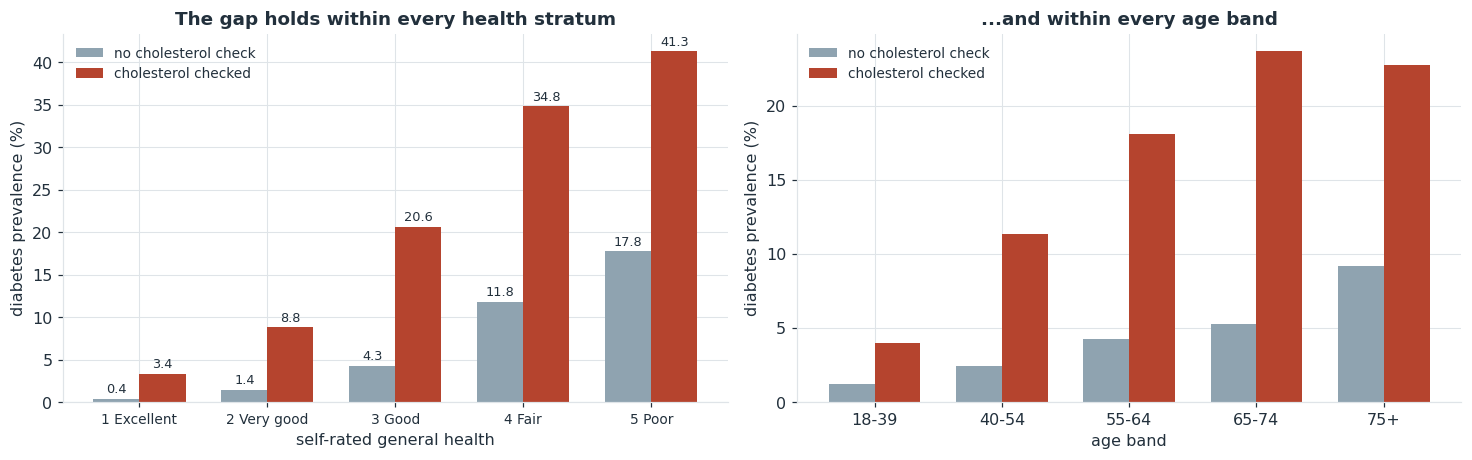

respondents per cell, left panel:


CholCheck,0.0000,1.0000
GenHlth,,
1.0000,2334,42965
2.0000,3599,85485
3.0000,2533,73113
4.0000,762,30808
5.0000,242,11839


In [157]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.3))

ax = axes[0]
piv = (raw.groupby(["GenHlth","CholCheck"])[TARGET].mean().unstack()*100)
w = .36; x = np.arange(len(piv))
ax.bar(x-w/2, piv[0.0], w, color=PALETTE["neg"], label="no cholesterol check")
ax.bar(x+w/2, piv[1.0], w, color=PALETTE["pos"], label="cholesterol checked")
for i in x:
    ax.text(i-w/2, piv[0.0].iloc[i]+.7, f"{piv[0.0].iloc[i]:.1f}", ha="center", fontsize=8.4)
    ax.text(i+w/2, piv[1.0].iloc[i]+.7, f"{piv[1.0].iloc[i]:.1f}", ha="center", fontsize=8.4)
ax.set_xticks(x); ax.set_xticklabels(GH_LAB, fontsize=9)
ax.set_xlabel("self-rated general health"); ax.set_ylabel("diabetes prevalence (%)")
ax.set_title("The gap holds within every health stratum"); ax.legend(fontsize=9)

ax = axes[1]
ac = (raw.assign(agegrp=AGE_GRP).groupby(["agegrp","CholCheck"], observed=True)[TARGET]
         .mean().unstack()*100)
ac.plot(kind="bar", ax=ax, color=[PALETTE["neg"], PALETTE["pos"]], width=.72, rot=0)
ax.set_xlabel("age band"); ax.set_ylabel("diabetes prevalence (%)")
ax.set_title("...and within every age band")
ax.legend(["no cholesterol check","cholesterol checked"], fontsize=9)
plt.tight_layout(); plt.show()

print("respondents per cell, left panel:")
display(pd.crosstab(raw.GenHlth, raw.CholCheck).astype(int))

The gap does not close. Among respondents who rate their own health as poor, those without a recent cholesterol
check still report far less diabetes. The simplest explanation is that a meaningful
share of them have undiagnosed diabetes and are recorded as negatives.

This matters for how the data is used. A model that leans on `CholCheck`,
`AnyHealthcare` or `NoDocbcCost` will score well while learning to detect
healthcare contact rather than disease. Deployed for screening it would under-flag
exactly the uninsured, low-income population that most needs screening.

The table below groups the features by their role relative to the outcome. Nothing
here is measured over time, so the ordering comes from the meaning of each
question rather than from the data.

In [158]:
timing = pd.DataFrame([
 ("Age","antecedent","fixed"),
 ("Sex","antecedent","fixed"),
 ("Education","antecedent","largely fixed by adulthood"),
 ("Income","antecedent","can be affected by illness, but weakly"),
 ("BMI","risk factor","plausibly causal, precedes onset"),
 ("Smoker","risk factor","lifetime measure, precedes onset"),
 ("HighBP","risk factor","shares causes with diabetes, often precedes"),
 ("HighChol","risk factor","shares causes with diabetes, often precedes"),
 ("HvyAlcoholConsump","current behaviour","may change after diagnosis"),
 ("Fruits","current behaviour","may change after diagnosis"),
 ("Veggies","current behaviour","may change after diagnosis"),
 ("PhysActivity","current behaviour","may change after diagnosis"),
 ("MentHlth","ambiguous","bidirectional with chronic illness"),
 ("CholCheck","access","measures healthcare contact, not disease"),
 ("AnyHealthcare","access","measures healthcare contact, not disease"),
 ("NoDocbcCost","access","measures healthcare contact, not disease"),
 ("GenHlth","consequence","self-rating is informed by knowing the diagnosis"),
 ("PhysHlth","consequence","symptom burden follows disease"),
 ("DiffWalk","consequence","neuropathy is a diabetes complication"),
 ("HeartDiseaseorAttack","consequence","diabetes is a major cause of CHD"),
 ("Stroke","consequence","diabetes is a major cause of stroke"),
], columns=["feature","role","reasoning"])

display(timing.set_index("feature"))
print(timing.role.value_counts().to_string())

,role,reasoning
feature,,
Age,antecedent,fixed
Sex,antecedent,fixed
Education,antecedent,largely fixed by adulthood
Income,antecedent,"can be affected by illness, but weakly"
BMI,risk factor,"plausibly causal, precedes onset"
Smoker,risk factor,"lifetime measure, precedes onset"
HighBP,risk factor,"shares causes with diabetes, often precedes"
HighChol,risk factor,"shares causes with diabetes, often precedes"
HvyAlcoholConsump,current behaviour,may change after diagnosis


role
consequence          5
antecedent           4
risk factor          4
current behaviour    4
access               3
ambiguous            1


> **Takeaway.** Choose the feature set to match the purpose.
>
> - **Risk stratification** — who should be screened? Use the antecedents, risk
>   factors and current behaviours; drop the access and consequence variables.
>   Expect a lower AUC and a more honest one.
> - **Association description** — use everything, but label the access variables so
>   they are not read as risk factors.
>
> State which of these the model is doing before reporting a single metric.

---
## 12. External data that would extend this analysis

Each item addresses a specific limitation identified above.

### Recovering what the extract dropped

**BRFSS 2015 full public-use file (CDC).** The highest-value addition and freely
available. It restores:

- `_LLCPWT`, `_STSTR` and `_PSU`, the survey weights and design variables, without
  which none of the prevalence figures generalise beyond this sample (§1).
- `_STATE`, the geographic key that every dataset below needs for joining (§1).
- The rows removed by the complete-case filter, with refusal codes intact, so
  missingness can be modelled rather than assumed away (§2.2).
- `DIABAGE2` (age at diagnosis) and `PREDIAB1` (told you have prediabetes). Age at
  diagnosis converts the binary target into a time-to-event outcome and would let
  the age reversal in §6.1 be modelled directly rather than only flagged.
- `CHECKUP1` (time since last routine checkup) and `MEDCOST`, giving a richer
  measure of healthcare contact than the three access columns available here (§11).

**BRFSS 2011–2023 waves.** Repeated cross-sections add a time dimension: whether
the socio-economic gradient in §8 is widening, and whether the 2014 Medicaid
expansions changed the access-to-diagnosis relationship in §11. That second
question comes close to a natural experiment on undiagnosed diabetes.

### Testing the ascertainment hypothesis

**NHANES (CDC).** The dataset that would settle §11. NHANES measures fasting
glucose and HbA1c alongside the same self-report questions, so it contains both
"has diabetes" and "knows they have diabetes". It would allow:

- estimating the undiagnosed fraction by insurance status, income and age, and
  building a correction factor for the BRFSS label;
- checking whether the `CholCheck` association shrinks when the outcome is a lab
  value rather than a self-report — a direct test of the §11 argument;
- calibrating BMI, since NHANES measures height and weight rather than asking,
  which would quantify the self-report bias behind the §2.3 artifact.

NHANES is much smaller (~10k per cycle) but supplies the ground truth this file
lacks.

### Adding what the survey cannot observe

**USDA Food Access Research Atlas.** `Fruits` and `Veggies` are weak here, partly
because self-reported intake is noisy and partly because diet is constrained by
supply. Food-desert status, distance to a supermarket and SNAP participation supply
the environmental half of that story. Requires geography.

**CDC PLACES.** Model-based small-area estimates of diabetes, obesity, inactivity
and insurance coverage at census-tract level. Useful both as contextual features
and as an external validation target: predicted prevalence by area should track
PLACES.

**County Health Rankings (RWJF).** County-level primary-care physician density,
uninsured rate and food environment index. Physician density is a clean proxy for
the access channel in §11 — areas with more doctors should show higher *diagnosed*
prevalence at equal true prevalence.

**Census ACS 5-year estimates.** Tract-level income, education and insurance,
allowing individual socio-economic status to be separated from neighbourhood
socio-economic status. §8 establishes a strong individual gradient; the contextual
effect is invisible in this file.

### If only one addition were possible

Take the full BRFSS 2015 file. It is the same survey, freely available, and it
restores the survey weights, the geography key, the deleted rows and the age at
diagnosis at once — four of the main limitations documented here. Every external
join described above depends on the geography key it provides.

---

### Reproducibility note

All figures and tables were computed from the file as distributed, with no rows
dropped and no values imputed. `bmi_cat` and `bmi_winsor` were added in §2.4; the
duplicate rows discussed in §3 were retained throughout. Where a transformation is
recommended, it is recommended for the modelling stage and left out of the EDA so
the two remain separable.

---
## Appendix. PCA and t-SNE on the full candidate set

Sections 5-11 argued for carrying all 21 predictors into the modelling stage.
This appendix looks at them together. Every candidate feature is standardised so
the binary and ordinal columns enter on a common scale, and the resulting
21-dimensional cloud is projected to two dimensions two ways -- linearly with
PCA and non-linearly with t-SNE -- coloured by diabetes status.

PCA is deterministic and cheap, so it runs on the full sample. t-SNE does not
scale to 253,680 rows, so it uses a fixed 30,000-row random subsample; the PCA
panel is drawn on the same rows so the two views are directly comparable. The
subsample and the embedding are reused in A.2, so this cell runs once.


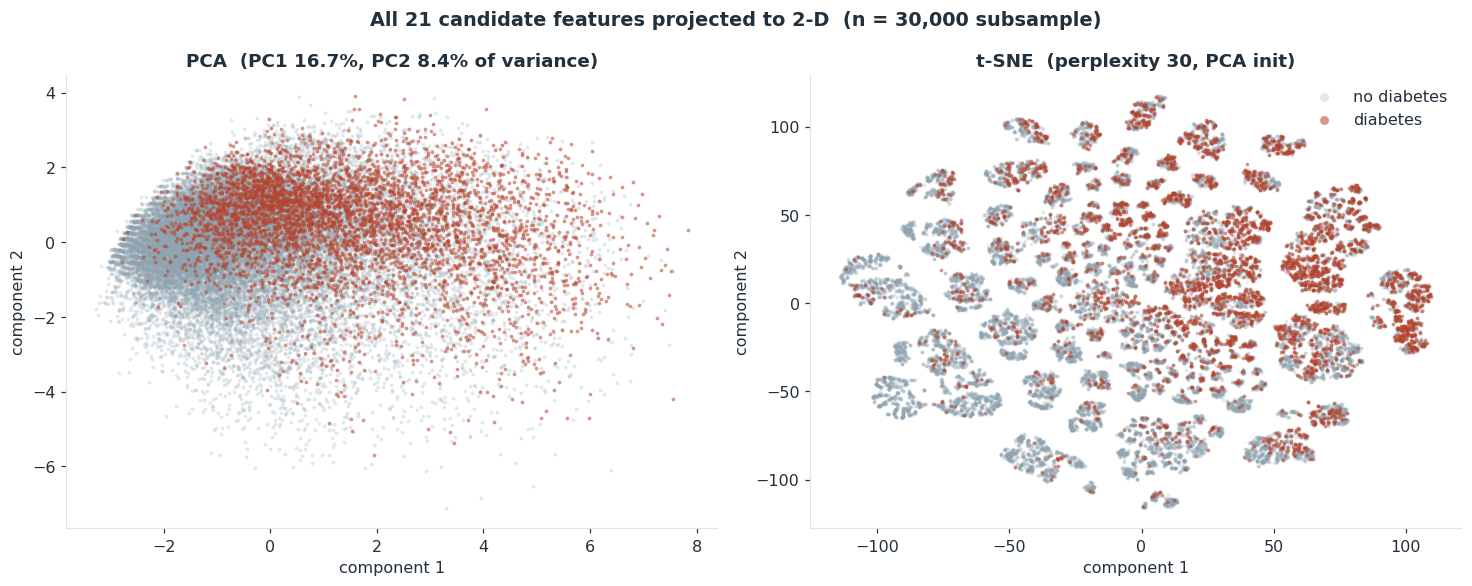

PCA explained variance : PC1 16.7%, PC2 8.4%, first two together 25.1%
t-SNE subsample        : 30,000 rows (11.8% of the file); diabetes prevalence 15.73% vs 15.76% overall


In [159]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

TSNE_N = 30_000

X = StandardScaler().fit_transform(raw[FEATURES].astype(float))
y = raw[TARGET].values

pca = PCA(n_components=2, random_state=0).fit(X)
pc  = pca.transform(X)
evr = pca.explained_variance_ratio_

rng = np.random.default_rng(0)
idx = rng.choice(len(X), size=TSNE_N, replace=False)
emb = TSNE(n_components=2, perplexity=30, init="pca",
           learning_rate="auto", random_state=0).fit_transform(X[idx])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4))

for ax, xy, title in [
    (axes[0], pc[idx], f"PCA  (PC1 {evr[0]*100:.1f}%, PC2 {evr[1]*100:.1f}% of variance)"),
    (axes[1], emb,     "t-SNE  (perplexity 30, PCA init)"),
]:
    m = y[idx] == 0
    ax.scatter(xy[m, 0],  xy[m, 1],  s=6, alpha=.25, linewidths=0,
               color=PALETTE["neg"], label="no diabetes")
    ax.scatter(xy[~m, 0], xy[~m, 1], s=6, alpha=.55, linewidths=0,
               color=PALETTE["pos"], label="diabetes")
    ax.set_title(title)
    ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
    ax.grid(visible=False)

axes[1].legend(markerscale=2.4, loc="best")
fig.suptitle(f"All {len(FEATURES)} candidate features projected to 2-D  "
             f"(n = {len(idx):,} subsample)", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"PCA explained variance : PC1 {evr[0]*100:.1f}%, PC2 {evr[1]*100:.1f}%, "
      f"first two together {evr[:2].sum()*100:.1f}%")
print(f"t-SNE subsample        : {len(idx):,} rows "
      f"({100*len(idx)/len(X):.1f}% of the file); diabetes prevalence "
      f"{100*y[idx].mean():.2f}% vs {100*y.mean():.2f}% overall")


### A.1 What the two projections show

Neither projection separates the classes, but both are informative anyway.

The principal components do carry a risk signal, with the diabetic cloud shifted
to the right along PC1. But PC1 and PC2 together hold only about a quarter of the
variance, so no two-dimensional linear summary can be faithful here. There are no
hard boundaries, and the two distributions overlap throughout.

The t-SNE panel breaks into dozens of small islands, which is expected when the
columns are predominantly binaries and short ordinals. t-SNE pulls similar rows
into tight blobs, so the islands are an artifact of the survey structure — the
same limited resolution that drove the high duplicate rate in §3. Island
composition is the informative part. Some islands are bleeding red, others grey,
and the mixed ones are where people with identical answers had different outcomes.

One caution on reading the colour. The positive class is drawn second, so at 15.76%
prevalence red overdraws grey and any region looks redder than its true proportion.
Judgements about how diabetic a region is belong to a tabulation, not to this
picture.


### A.2 Finding the never-screened

§11 showed that `Diabetes_binary` records diagnosis, not disease, and that a
cholesterol check is the point at which a diagnosis becomes possible. Screened
respondents therefore know their status; unscreened ones are coded 0 either way.
If that holds, some respondents match the diabetic population on every clinical
measure and are coded 0 only because nobody looked. `CholCheck` = 0 marks the
9,470 respondents who could be in that position.

Three steps.

**Score risk without the screening channel.** A gradient-boosted model is fitted
on the 244,210 screened respondents, where a negative label is credible, using the
18 clinical, anthropometric, behavioural and demographic features with the access
columns withheld. Withholding them is the point: a model given `CholCheck` would
learn *never screened, therefore never diagnosed* and reproduce the bias instead
of exposing it. Screened scores are out-of-fold; the never-screened are scored by
a model that never saw them.

**Count the missing diagnoses.** Summing the score over the never-screened gives
the diagnoses their risk profile predicts. The gap between that and the number
recorded is a standardised morbidity ratio — a shortfall in diagnoses, not in
disease. The calibration is internal, with no external prevalence assumed, and
because `Age` and `BMI` are in the model it already adjusts for the never-screened
skewing young and lean. The other two access flags run through the same
calculation as a reference.

**Locate them.** The never-screened carrying the top of that shortfall are marked
in the embedding from the previous cell.


,respondents,diagnoses recorded,diagnoses expected,shortfall,recorded/expected
group,,,,,
cholesterol checked,244210,39674,"39,638.3600",-35.6400,1.0000
never screened,9470,303,787.3000,484.3000,0.3800


risk model : 18 features, access columns withheld, trained on the 244,210 screened respondents
             out-of-fold AUC 0.821; recorded/expected 1.00 confirms the model is calibrated on that stratum
flagged    : the 484 never-screened respondents coded 0 with the highest risk (>= 0.282), one per missing diagnosis
left panel  : all 9,470 never-screened plus 20,530 screened, so the never-screened are over-represented (32% of the panel vs 3.7% of the file)


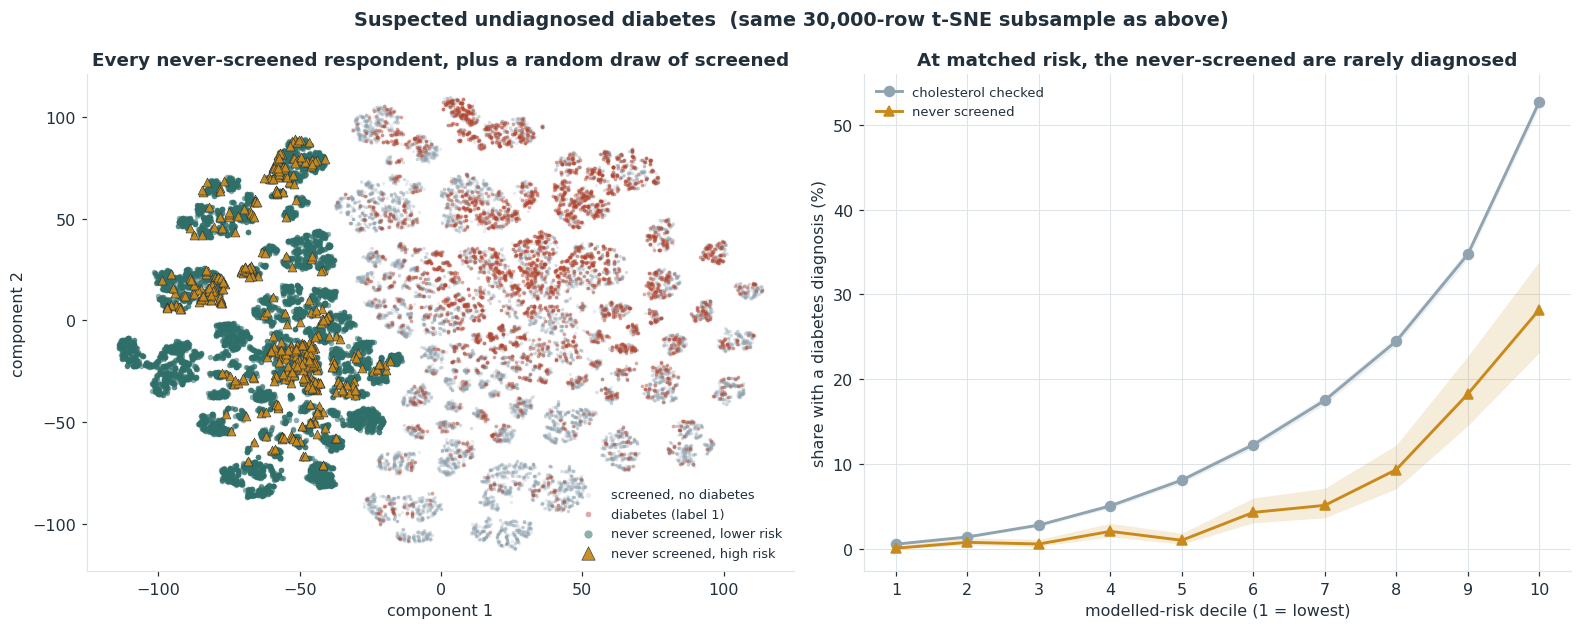

,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
"screened, coded 0",0.3800,0.3900,27.7700,0.4300,0.0300,0.0700,0.7800,0.6500,0.8200,0.0600,2.3800,2.9200,3.6200,0.1300,0.4300,7.8400,5.1100,6.2200
flagged,0.7600,0.6900,34.0900,0.6000,0.0700,0.1700,0.5100,0.4700,0.7300,0.0200,3.6700,6.6000,9.8600,0.4400,0.5100,8.5500,4.5200,4.2700
diagnosed,0.7400,0.6600,31.8000,0.5200,0.0900,0.2100,0.6400,0.5900,0.7600,0.0300,3.2500,4.4700,7.7700,0.3600,0.4700,9.3400,4.7500,5.2300


respondents per risk decile:


decile,1,2,3,4,5,6,7,8,9,10
screened,23644,23775,23920,24144,24359,24621,24742,24875,25028,25102
never screened,1724,1602,1439,1224,1009,747,626,493,340,266


In [160]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

ACCESS   = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
RISK_FEA = [c for c in FEATURES if c not in ACCESS]

y        = raw[TARGET].to_numpy(int)
screened = raw.CholCheck.eq(1).to_numpy()
Xr       = raw[RISK_FEA].to_numpy(float)

clf = HistGradientBoostingClassifier(max_depth=4, learning_rate=.06, max_iter=400,
                                     l2_regularization=1.0, random_state=0)

risk = np.empty(len(raw))
risk[screened] = cross_val_predict(
    clf, Xr[screened], y[screened], method="predict_proba", n_jobs=-1,
    cv=StratifiedKFold(5, shuffle=True, random_state=0))[:, 1]
risk[~screened] = clf.fit(Xr[screened], y[screened]).predict_proba(Xr[~screened])[:, 1]

books = pd.DataFrame(
    [(lab, int(m.sum()), int(y[m].sum()), risk[m].sum())
     for lab, m in [("cholesterol checked", screened),
                    ("never screened",      ~screened)]],
    columns=["group", "respondents", "diagnoses recorded", "diagnoses expected"])
books["shortfall"]         = books["diagnoses expected"] - books["diagnoses recorded"]
books["recorded/expected"] = books["diagnoses recorded"] / books["diagnoses expected"]
display(books.round(2).set_index("group"))

gap     = max(int(round(books.shortfall.iloc[1])), 0)
cand    = (~screened) & (y == 0)
thr     = np.quantile(risk[cand], 1 - gap/cand.sum()) if gap else np.inf
suspect = cand & (risk >= thr)

print(f"risk model : {len(RISK_FEA)} features, access columns withheld, trained on "
      f"the {screened.sum():,} screened respondents")
print(f"             out-of-fold AUC {roc_auc_score(y[screened], risk[screened]):.3f}; "
      f"recorded/expected {books['recorded/expected'].iloc[0]:.2f} confirms the model "
      f"is calibrated on that stratum")
print(f"flagged    : the {suspect.sum():,} never-screened respondents coded 0 with the "
      f"highest risk (>= {thr:.3f}), one per missing diagnosis")

ns_rows = np.flatnonzero(~screened)
sub     = np.concatenate([ns_rows, np.random.default_rng(1).choice(
              np.flatnonzero(screened), size=TSNE_N - len(ns_rows), replace=False)])
emb_ns  = TSNE(n_components=2, perplexity=30, init="pca",
               learning_rate="auto", random_state=0).fit_transform(X[sub])

print(f"left panel  : all {len(ns_rows):,} never-screened plus {TSNE_N - len(ns_rows):,} "
      f"screened, so the never-screened are over-represented "
      f"({100*len(ns_rows)/TSNE_N:.0f}% of the panel vs "
      f"{100*len(ns_rows)/len(raw):.1f}% of the file)")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8))

ax = axes[0]
lab, ns, sus = y[sub].astype(bool), (~screened)[sub], suspect[sub]
for m, style, name in [
    (~lab & ~ns, dict(c=PALETTE["neg"],  marker="o", s=5,  alpha=.20, lw=0),
     "screened, no diabetes"),
    (lab,        dict(c=PALETTE["pos"],  marker="o", s=6,  alpha=.45, lw=0),
     "diabetes (label 1)"),
    (ns & ~sus,  dict(c=PALETTE["prot"], marker="o", s=13, alpha=.55, lw=0),
     "never screened, lower risk"),
    (sus,        dict(c=PALETTE["accent"], marker="^", s=34, alpha=.95, lw=.4,
                      edgecolors=PALETTE["ink"]), "never screened, high risk"),
]:
    ax.scatter(emb_ns[m, 0], emb_ns[m, 1], label=name, **style)
ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
ax.set_title("Every never-screened respondent, plus a random draw of screened")
ax.grid(visible=False)
ax.legend(markerscale=1.5, loc="best", fontsize=8.4)

ax = axes[1]
dec = np.clip(np.searchsorted(np.quantile(risk, np.linspace(0, 1, 11))[1:-1], risk), 0, 9)
for m, c, mk, name in [(screened,  PALETTE["neg"],    "o", "cholesterol checked"),
                       (~screened, PALETTE["accent"], "^", "never screened")]:
    k = np.array([y[m & (dec == d)].sum()  for d in range(10)])
    n = np.array([(m & (dec == d)).sum()   for d in range(10)])
    lo, hi = zip(*[wilson(int(a), int(b)) for a, b in zip(k, n)])
    ax.plot(range(1, 11), 100*k/n, marker=mk, color=c, lw=1.9, ms=6.5, label=name)
    ax.fill_between(range(1, 11), 100*np.array(lo), 100*np.array(hi),
                    color=c, alpha=.16, lw=0)
ax.set_xlabel("modelled-risk decile (1 = lowest)")
ax.set_ylabel("share with a diabetes diagnosis (%)")
ax.set_title("At matched risk, the never-screened are rarely diagnosed")
ax.set_xticks(range(1, 11)); ax.legend(fontsize=8.6)

fig.suptitle(f"Suspected undiagnosed diabetes  (same {len(idx):,}-row t-SNE "
             f"subsample as above)", fontweight="bold")
plt.tight_layout(); plt.show()

display(pd.DataFrame({
    "screened, coded 0": raw.loc[screened & (y == 0), RISK_FEA].mean(),
    "flagged":           raw.loc[suspect,             RISK_FEA].mean(),
    "diagnosed":         raw.loc[y == 1,              RISK_FEA].mean(),
}).round(2).T)

print("respondents per risk decile:")
display(pd.DataFrame(
    {"screened":       [int((screened  & (dec == d)).sum()) for d in range(10)],
     "never screened": [int(((~screened) & (dec == d)).sum()) for d in range(10)]},
    index=pd.Index(range(1, 11), name="decile")).T)

The right-hand panel carries the argument. Both groups are ranked by the same
score, built without any access variable, so a given decile holds people with
matching clinical profiles. Through decile 5 the two lines sit together. That's expected, because amongst the low risk population, there is nothing to miss.. From decile 6 the never-screened line
falls away, and in the top decile 52.5% of screened respondents are diagnosed
against 28.1% of the never-screened. The hypothesis is that gap represents undiagnosed disease.

The ledger quantifies the problem. The never-screened carry 303 recorded diagnoses against 787
their risk profile predicts: 484 missing, more than the number on file. Credit them
and the group moves from 3.20% to 8.31%.

The left-hand panel locates the undiagnosed. The never-screened occupy their own half of the
embedding. At 3.7% of the file, `CholCheck` = 0 is a rare flag, and after
standardisation a rare flag dominates Euclidean distance. Most of that territory is
low-risk teal: young, lean people with no particular reason to have been screened.
The gold triangles concentrate in a handful of islands within it, and the profile
table shows why they matter. On BMI (34.1 vs 31.8), `HighBP`, `GenHlth` and
`DiffWalk` the flagged group is worse than the diagnosed population, while being
younger and poorer. These are not marginal cases.

One limit. BRFSS carries no HbA1c or fasting glucose, so nothing here is
confirmable: a triangle means *this negative label is not trustworthy*, not *this
person has diabetes*. NHANES, which measures both, is what would settle it (§12).

> **Takeaway.** `CholCheck` is not a risk factor. It marks whether the outcome
> could have been observed at all. That fixes the modelling plan. Train the
> classifier on the 244,210 screened respondents, where a negative label is
> credible, using the 18 non-access features. Then apply it to the 9,470
> never-screened as the deployment target, and report their scores as risk
> estimates rather than scoring them against `Diabetes_binary` — the label is
> wrong for roughly 484 of them by construction. Screening those the model ranks
> highest is the intended use.